## 1. Introduction: Crime in Los Angeles

### 1.1 Executive Summary

Living in the big city can offer many amenities by virtue of the larger population and the resources available to an individual. We recently moved to Chicago from Lincoln, Nebraska and were overwhelmed by the range of "things" in the city. Rather than a rather flat monoculture, every neighborhood had its own unique personality, and there was a wide range of people from different backgrounds to meet. However, whenever people gather in concentration, frictions can arise and bad behaviors can be encouraged by the sheer number of opportunities that present themselves to a dishonest individual every day. Understanding crime patterns can be essential for safety, resource planning, and policy decision making. 

### 1.2 Problem Statement

We seek to investigate the LA Crimes data set to better understand trends over time, especially post COVID, trends over locations across different neighborhoods, and relationships between crime types, time of day, time of year, and other factors. Insights can help law enforcement focus resources in the right areas. Policemen (and everyone living in the city) have a feel for which areas are more dangerous, but we can formalize these feelings with hard data based on reporting statistics. Additionally, this data includes demographic information. A hot topic is disproportionate police response to different races, and hopefully we can uncover some of the relationships here to see if there is indeed a discrepancy.

One of the main shortfalls of crime data is that the information is collected through the lens of those reporting the crime, often police officers. This introduces problems with missing data, hastily prepared reports, or inaccuracies. But this also introduces biases from police officers, who may underreport crimes committed in certain neighborhoods, by certain demographics, whether age or race or another statistic. 

Our goal is to see what insights we can pull from this crime data set, to see if we could potentially Minority Report-style predict crimes and plan accordingly, and to see if there are biases present in crime reporting in general.

## 2. Data Sources and Preparation

### 2.1 Importing necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from collections import Counter
import scipy.stats as ss
import matplotlib.dates as mpldates

%matplotlib inline
import pymc
import arviz as az
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

import warnings

warnings.filterwarnings("ignore",module="arviz.stats.density_utils",)
warnings.filterwarnings("ignore", message="Could not infer format", category=UserWarning,)
warnings.filterwarnings("ignore", message=".*BLAS.*")


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


### 2.2 Data Description
Data was downloaded from [this page on data.gov](https://catalog.data.gov/dataset/crime-data-from-2020-to-present) and metadata was sourced from [this page at lacity.org](https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8/about_data). The data is a record of over 1 million crimes committed and logged in LA from 2020 onwards. There are 28 columns, with instance ID, date, time, location, description of the crime, and some other variables.

In [2]:
## Full Data Set (Originally Downloaded Nov 13, 2025)
lacrime = pd.read_csv("../axproj/Crime_Data_from_2020_to_Present.csv", 
                 low_memory =False,
                 parse_dates = ["Date Rptd", "DATE OCC"]
                 ) ## Full Data Set

## Metadata from LACity.org 
MO_codes = pd.read_csv("../axproj/MO_Codes_Numerical.csv")  ## Modus Operandi codes

map_desc = dict( ## meta_data map for victim descent
    A="Other Asian", B="Black", C="Chinese", D="Cambodian",
    F="Filipino", G="Guamanian", H="Hispanic/Latin/Mexican",
    I="American Indian/Alaskan Native", J="Japanese", K="Korean",
    L="Laotian", O="Other", P="Pacific Islander", S="Samoan",
    U="Hawaiian", V="Vietnamese", W="White", X="Unknown",
    Z="Asian Indian"
)

lacrime.shape


(1004991, 28)

In [3]:
lacrime.dtypes

DR_NO                      int64
Date Rptd         datetime64[ns]
DATE OCC          datetime64[ns]
TIME OCC                   int64
AREA                       int64
AREA NAME                 object
Rpt Dist No                int64
Part 1-2                   int64
Crm Cd                     int64
Crm Cd Desc               object
Mocodes                   object
Vict Age                   int64
Vict Sex                  object
Vict Descent              object
Premis Cd                float64
Premis Desc               object
Weapon Used Cd           float64
Weapon Desc               object
Status                    object
Status Desc               object
Crm Cd 1                 float64
Crm Cd 2                 float64
Crm Cd 3                 float64
Crm Cd 4                 float64
LOCATION                  object
Cross Street              object
LAT                      float64
LON                      float64
dtype: object

We add metadata from the Los Angeles city website. Metadata includes a description of MO Codes, which are Modus Operandi codes. We also include a dictionary that describes victim descent.

### 2.3 Data clean up and preparation
In preparation, we clean up some of the time data formatting and add in indicators or nulls where data is unavailable. As this data is dependent on manual entry, missing or default values can cause issues in further analysis. For example, there are no crimes committed by people of age 0 (I hope). 

In data clean up (subject to do more):
* Standardize time to a 4 digit string
* Add in metrics for hour, minute, month, and day
* Cast time to a float number that we can run regressions on
* Include missing indicators for locations registered as 0, 0 because LA exists in a specific latitude and longitude
* Remove 0 values from age

We add some potential regression variables (subject to add more):
* report_delay - the delay between the time a crime was reported and when it occurred
* severity - a 1 to 3 score, based on whether the crime was Part 1 (score 2) or Part 2 (score 1), with an extra +1 if a weapon was recorded. Part 1 crimes include violent and property crimes, while part 2 encompass just about everything else, like vandalism and drug offenses
* area_score - a daily count per area
* complexity - a count of the number of Crime Codes associated with each crime. This is subject to manual entry decisions, but we could potentially uncover reporting consistency issues

In [4]:
# clean up function
def clean_lacrime(df):
    df = df.copy() 

    # df['DATE OCC']  = pd.to_datetime(df['DATE OCC'],  format="%m/%d/%Y", errors="coerce")
    # df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], format="%m/%d/%Y", errors="coerce")

    df['TIME OCC'] = df['TIME OCC'].astype(str).str.zfill(4) # standardize time
    df['hour'] = df['TIME OCC'].str[:2].astype(int)
    df['minute'] = df['TIME OCC'].str[2:].astype(int)
    df['time_float'] = df['hour'] + df['minute']/60.0
    df['month'] = df['DATE OCC'].dt.month
    df['day'] = df['DATE OCC'].dt.day
    df['year'] = df['DATE OCC'].dt.year
    # df['week_of_year'] = df['DATE OCC'].dt.isocalendar().week
 
    df['loc_missing'] = ((df['LAT'] == 0) & (df['LON'] == 0)).astype(int) # missing loc indicator
    df['Vict Age'] = df['Vict Age'].replace(0, np.nan) # clean missing age victim

    df['LAT_std'] = (df['LAT'] - df['LAT'].mean()) / df['LAT'].std() # standardize location
    df['LON_std'] = (df['LON'] - df['LON'].mean()) / df['LON'].std()

    # deal with blanks in weapon codes and mocodes
    df['Weapon Used Cd'] = df['Weapon Used Cd'].fillna(0)
    df['Weapon Desc'] = df['Weapon Desc'].fillna("n/a")
    
    # fill in empty mocodes with 0000 instead of 'na'
    df['Mocodes'] = df['Mocodes'].fillna("0000") 
    
    # removing spaces from some variables
    df['AREA'] = df['AREA NAME']
    df['vDescent'] = df['Vict Descent']

    # add a sequential month and sequential year
    df['month_seq'] = (df['year'] - df['year'].min()) * 12 + df['month']
    df['week_seq'] = ((df['DATE OCC'] - df['DATE OCC'].min()).dt.days // 7) + 1

    return df

# potential regression targets
def add_regression_vars(df):
    df = df.copy()
    df['report_delay'] = (df['Date Rptd'] - df['DATE OCC']).dt.days # delay in reporting
    df['weapon_cd'] = df['Weapon Used Cd'].fillna(0) # fill in 0s when weapon code is n
    df['severity'] = 3 - (df['Part 1-2'] + np.where(df['weapon_cd'] > 0, -1, 0)) # 1,2,3 severity scale based on weapon usage and Part 1-2
    df['area_score'] = df.groupby(['AREA', 'DATE OCC']).transform('size') # count per area per day , use transform to index correctly
    df['complexity'] = df[['Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']].notnull().sum(axis = 1) # crime complexity based on number of codes
    return df


In [5]:
def series_center(series):
    return series - series.mean()
def series_center_z(series):
    return (series - series.mean())/(series.std())


def plotQQ(series):
    fig, ax = plt.subplots(figsize=(8, 8))
    ss.probplot(series, plot=ax)
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlim(-3, 3)
    ax.set_ylim(series.min(), series.max())


def clean_nan(df):
    cols = ['Vict Age', 'Premis Desc', 'Status']
    df = df.dropna(subset=cols)
    df = df[df['DATE OCC'].dt.year < 2024]
    return df

# convert sequential week back to a date
def week_seq_to_date(week_seq, start_date = '2020-01-01'):
    start_date = datetime.strptime(start_date, '%Y-%m-%d').date()
    days_diff = (week_seq - 1) * 7
    return start_date + timedelta(days = days_diff)

def month_seq_to_date(month_seq, start_date = '2020-01-01'):
    start_date = datetime.strptime(start_date, '%Y-%m-%d').date()
    return start_date + relativedelta(months = month_seq - 1)  


In [6]:
lacrime = clean_lacrime(lacrime)
lacrime = clean_nan(lacrime)
lacrime = add_regression_vars(lacrime)
# create dataframe of weapon usage
distinct_weapons = lacrime[['weapon_cd', 'Weapon Desc']].drop_duplicates()

In [7]:
lacrime[['Date Rptd','DATE OCC']].head()

,Date Rptd,DATE OCC
0,2021-04-11,2020-11-07
1,2020-10-21,2020-10-18
2,2024-12-10,2020-10-30
3,2020-12-24,2020-12-24
4,2020-10-03,2020-09-29


In [8]:
# create sample for excel look
sample = lacrime.head(10)
sample.to_csv("../axproj/sample2.csv")

## 3. Exploratory Data Analysis

### 3.1 EDA - Distributions

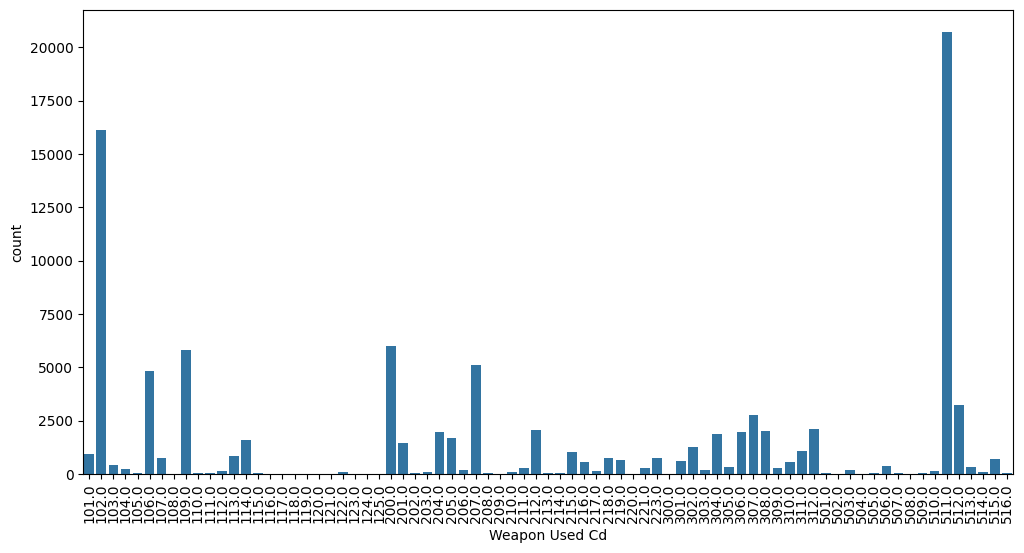

In [9]:
fig, ax = plt.subplots(figsize = (12, 8))
fig.subplots_adjust(bottom = 0.3)
# ax = sns.countplot(x = 'hour', data = lacrime, ax = ax)
sns.countplot(x = 'Weapon Used Cd', data = lacrime[~lacrime['Weapon Used Cd'].isin([0, 400, 500])], ax = ax)
ax.tick_params(axis='x', rotation=90)

Grouping: We should group categories by the 7 most common, then an 8th catch-all, unless we can find groupings for each of these.

In [10]:
twc = lacrime['Weapon Used Cd'].value_counts().head(20)
lacrime[lacrime['Weapon Used Cd'].isin(twc.index)].groupby(['Weapon Used Cd', 'Weapon Desc']).size().sort_values(ascending = False)

Weapon Used Cd  Weapon Desc                                   
0.0             n/a                                               379522
400.0           STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    154602
500.0           UNKNOWN WEAPON/OTHER WEAPON                        28126
511.0           VERBAL THREAT                                      20719
102.0           HAND GUN                                           16148
200.0           KNIFE WITH BLADE 6INCHES OR LESS                    6012
109.0           SEMI-AUTOMATIC PISTOL                               5822
207.0           OTHER KNIFE                                         5097
106.0           UNKNOWN FIREARM                                     4834
512.0           MACE/PEPPER SPRAY                                   3237
307.0           VEHICLE                                             2768
312.0           PIPE/METAL PIPE                                     2094
212.0           BOTTLE                                       

In [11]:
premis = lacrime['Premis Desc'].value_counts().head(20)
premis

Premis Desc
SINGLE FAMILY DWELLING                          146391
STREET                                          121140
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)    103083
PARKING LOT                                      42006
SIDEWALK                                         35014
VEHICLE, PASSENGER/TRUCK                         24206
OTHER BUSINESS                                   20588
GARAGE/CARPORT                                   12999
DRIVEWAY                                         10152
PARKING UNDERGROUND/BUILDING                      6467
RESTAURANT/FAST FOOD                              6268
OTHER RESIDENCE                                   5878
OTHER PREMISE                                     5411
ALLEY                                             5166
PARK/PLAYGROUND                                   4863
YARD (RESIDENTIAL/BUSINESS)                       4776
DEPARTMENT STORE                                  4533
HOTEL                                             425

In [12]:
premises = lacrime['Premis Desc'].astype(str).drop_duplicates().sort_values()
premises.shape
premises

86258     7TH AND METRO CENTER (NOT LINE SPECIFIC)
1497            ABANDONED BUILDING ABANDONED HOUSE
116857                          ABATEMENT LOCATION
120411          ABORTION CLINIC/ABORTION FACILITY*
39925                                     AIRCRAFT
                            ...                   
12413                        VISION CARE FACILITY*
472                                      WAREHOUSE
4304                                WATER FACILITY
1030                                       WEBSITE
7                      YARD (RESIDENTIAL/BUSINESS)
Name: Premis Desc, Length: 303, dtype: object

In [13]:
lacrime['Premis Desc'].astype(str).value_counts().head(20)

Premis Desc
SINGLE FAMILY DWELLING                          146391
STREET                                          121140
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)    103083
PARKING LOT                                      42006
SIDEWALK                                         35014
VEHICLE, PASSENGER/TRUCK                         24206
OTHER BUSINESS                                   20588
GARAGE/CARPORT                                   12999
DRIVEWAY                                         10152
PARKING UNDERGROUND/BUILDING                      6467
RESTAURANT/FAST FOOD                              6268
OTHER RESIDENCE                                   5878
OTHER PREMISE                                     5411
ALLEY                                             5166
PARK/PLAYGROUND                                   4863
YARD (RESIDENTIAL/BUSINESS)                       4776
DEPARTMENT STORE                                  4533
HOTEL                                             425

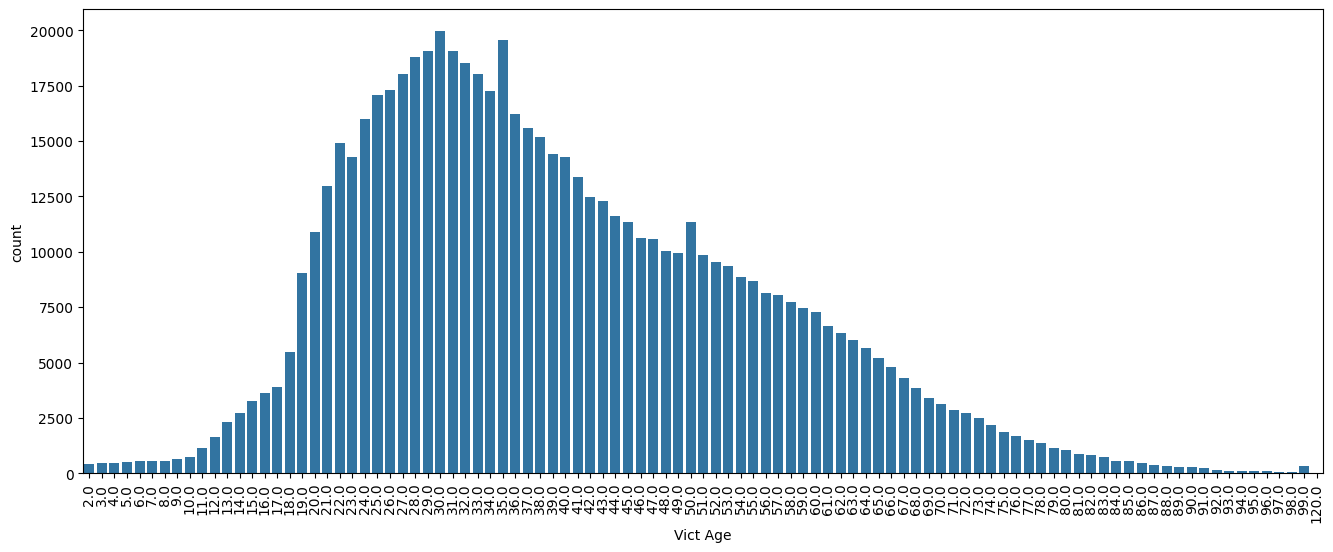

In [14]:
fig, ax = plt.subplots(figsize = (16, 8))
fig.subplots_adjust(bottom = 0.3)
# ax = sns.countplot(x = 'hour', data = lacrime, ax = ax)
sns.countplot(x = 'Vict Age', data = lacrime[lacrime['Vict Age'] > 0], ax = ax)
#35 year old seems to be the most common
ax.tick_params(axis='x', rotation=90)


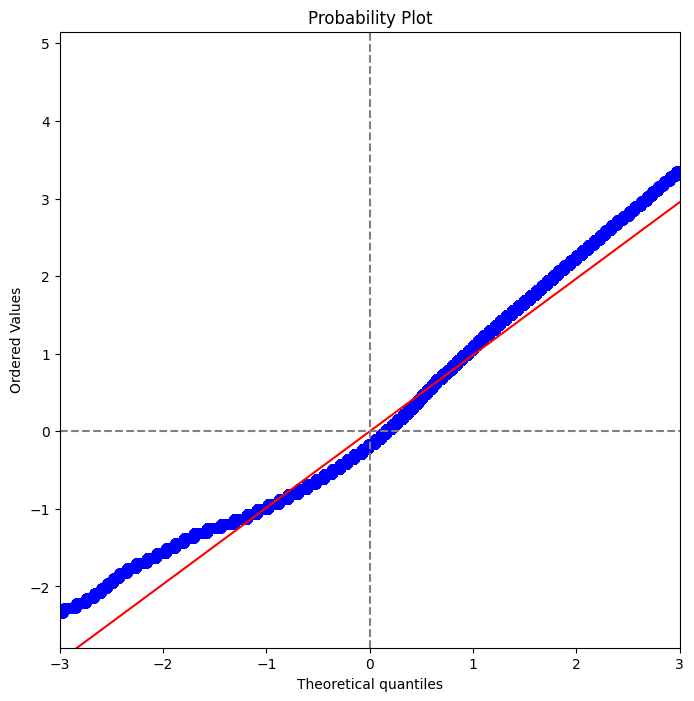

In [15]:
# plotQQ(series_center_z(lacrime['Vict Age'][~lacrime['Vict Age'].isna()]))
plotQQ(series_center_z(lacrime['Vict Age']))
# series_center_z(lacrime['Vict Age']).max()

In [16]:
lacrime['Vict Sex'].value_counts()

Vict Sex
M    331492
F    318836
X      8215
H        95
Name: count, dtype: int64

In [17]:
nomo = lacrime[['DR_NO','Mocodes']][lacrime['Mocodes'].isna()].head(5)
# lacrime[lacrime['DR_NO'].isin(nomo['DR_NO'])]['Mocodes']

In [18]:
lacrime['Mocodes'].head(10)

mo_lists = lacrime['Mocodes'].astype(str).str.split()
all_codes = mo_lists.explode()
# mo_lists.head()
# all_codes
mo_counts = all_codes.value_counts().reset_index()
# mo_counts.head(5)
mo_counts['Mocodes'] = mo_counts['Mocodes'].fillna(0).replace('nan',0)
# mo_counts
mo_counts['MO_code'] = mo_counts['Mocodes'].astype(int)
mo_counts_with_desc = mo_counts.merge(
    MO_codes,
    left_on='MO_code',
    right_on = 'MO_code',
    how = 'left'
)

mo_counts_with_desc.sort_values(by = 'count', ascending = False).head(15)


,Mocodes,count,MO_code,MO_desc
0,1822,255948,1822,Stranger
1,0344,221074,344,Removes vict property
2,0913,137826,913,Victim knew Suspect
3,0416,109471,416,Hit-Hit w/ weapon
4,0329,91195,329,Vandalized
5,1300,78000,1300,Vehicle involved
6,2000,68596,2000,Domestic violence
7,0400,64570,400,Force used
8,1814,43945,1814,Susp is/was current/former boyfriend/girlfriend
9,1402,41563,1402,Evidence Booked (any crime)


In [19]:
lacrime['Mocodes'].fillna("0000").value_counts(dropna = False).head(5)

Mocodes
0344         30067
0329         14055
1822 0344    10207
0344 1822     6655
1501          6169
Name: count, dtype: int64

### 3.2 EDA - Basic Statistics on Notable Variables

#### 3.2.1 Daily Volume

First, we take a look at the daily reporting volume. This is obviously time series data, and it is apparent that there is seasonality, especially per month. When we look at the crimes occuring by day of month, there is a heavy weight towards the beginning of the month. This could be due to meeting reporting quotas or perhaps a natural response to crimes committed to meet bills at the end of the month. More likely, first of the month is probably just the default reporting value when the reporter cannot remember the specific day that a crime happened.

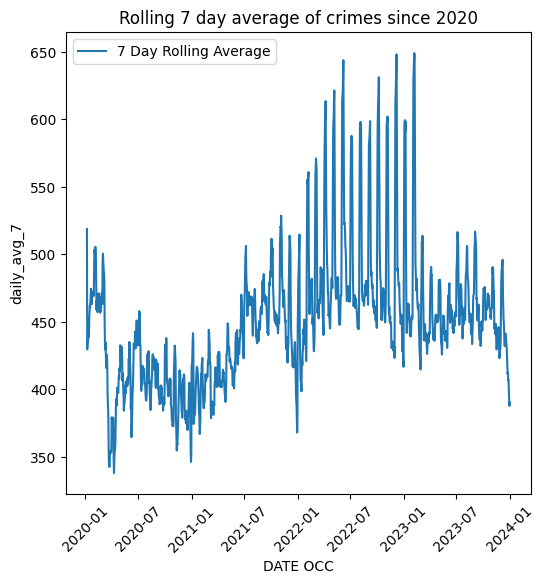

In [20]:
## daily volume
# shows serious potential reporting errors in data set - potentially remove time series data based on seasonality
daily_crimes = lacrime.groupby('DATE OCC').size().reset_index(name = 'crime_count')
plt.figure(figsize = (6,6))
daily_crimes['daily_avg_7'] = daily_crimes['crime_count'].rolling(7).mean()
sns.lineplot(data = daily_crimes, x = 'DATE OCC', y = 'daily_avg_7', label = '7 Day Rolling Average')
plt.title('Rolling 7 day average of crimes since 2020')
plt.gca().tick_params(axis='x', rotation=45)
plt.show()

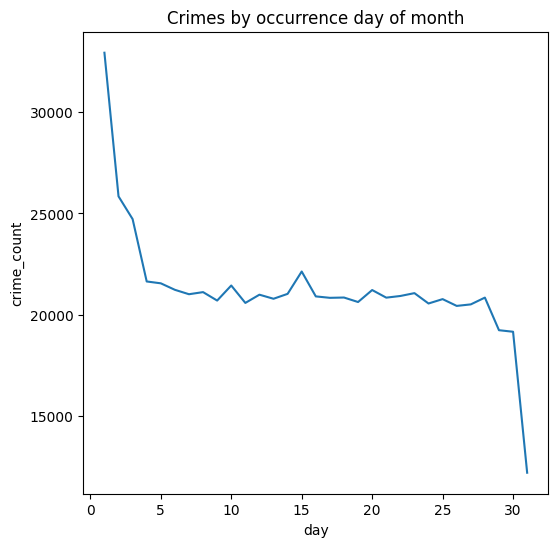

In [21]:
day_of_month_crimes = lacrime.groupby('day').size().reset_index(name = 'crime_count')
plt.figure(figsize = (6,6))
sns.lineplot(data = day_of_month_crimes, x = 'day', y = 'crime_count')
plt.title('Crimes by occurrence day of month')
plt.show()

#### 3.2.2 Daily Crimes By Area
Looking at number of daily crimes by area, there is too much noise for us to visualize properly. However, just looking at the total count of crimes, we can see that there are definitely higher crime areas. We explore this further down the page.

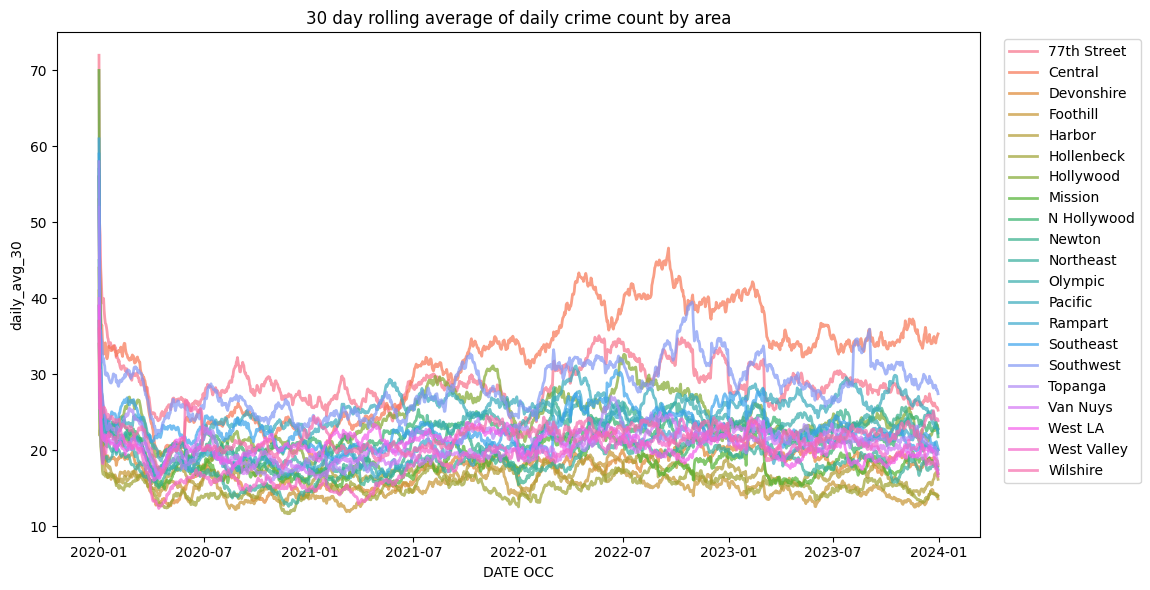

In [22]:
## rolling 30 daily volume by area. probably needs more development before it is useful
daily_crimes_area = lacrime.groupby(['DATE OCC', 'AREA NAME']).size().reset_index(name = 'crime_count')
daily_crimes_area['daily_avg_30'] = daily_crimes_area.sort_values(['AREA NAME', 'DATE OCC']).groupby('AREA NAME')['crime_count'].transform(lambda x: x.rolling(30, min_periods=1).mean())
plt.figure(figsize=(10,6))
ax = sns.lineplot(data = daily_crimes_area, x = 'DATE OCC', y = 'daily_avg_30', hue = 'AREA NAME', linewidth = 2, alpha = 0.7)
plt.title('30 day rolling average of daily crime count by area')
plt.tight_layout()
_ = ax.legend(loc = 'upper center', bbox_to_anchor=(1.1,1))

It seems that there is an increase in crime after a certain time around 2021. The overall spread of crimes widens after this point significantly.

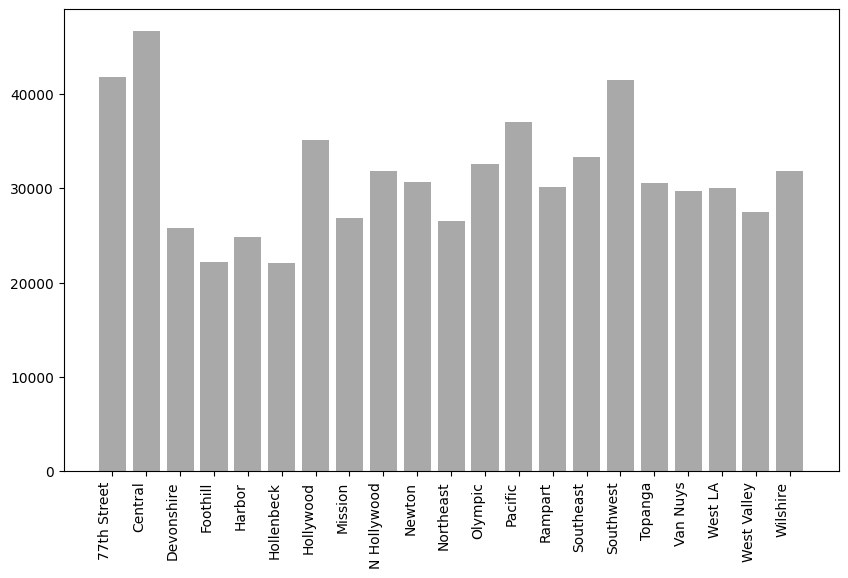

In [23]:
## show total crimes by area
crimes_area = lacrime.groupby(['AREA NAME']).size().reset_index(name = 'crime_count')
plt.figure(figsize=(10,6))
plt.bar(crimes_area['AREA NAME'],crimes_area['crime_count'], color = 'darkgrey')
plt.xticks(rotation = 90, ha='right')
plt.show()

#### 3.2.3 Time of day against type of crime
We restrict to the top 8 most common crimes, then evaluate what time of day they each occur. Identity theft has the most obvious trend, but it's more likely that reporters are putting in default values, as identity theft is probably harder to pinpoint the exact hour of as the victim doesn't always know immediately when their identity has been compromised. However, the more serious crimes such as assault, burglary, and vehicle theft seem to happen later in the night, which matches our common intuition. We could potentially predict the type of crime with other factors included in, such as area (perhaps latitude, longitude), day of month, etc. 

Text(0.5, 1.0, 'Day of time occurrence for top 8 crimes in LA')

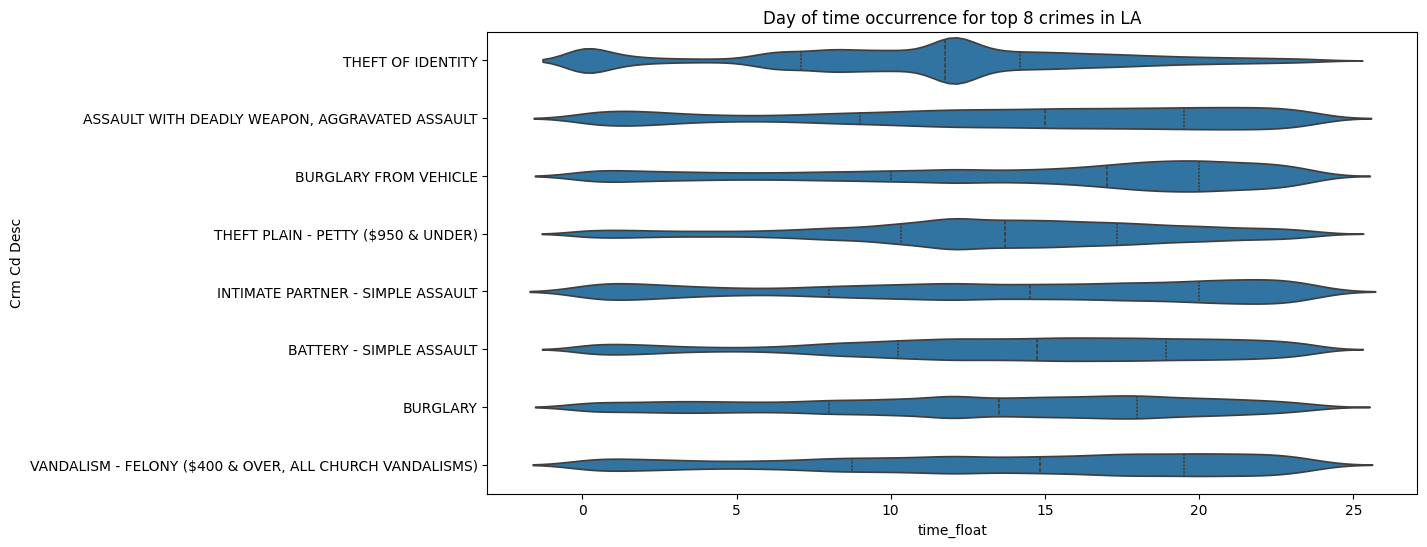

In [24]:
top_crimes = lacrime['Crm Cd Desc'].value_counts().head(8).index
toplacrime = lacrime[lacrime['Crm Cd Desc'].isin(top_crimes)]
plt.figure(figsize=(12,6))
sns.violinplot(data= toplacrime, y = 'Crm Cd Desc', x = 'time_float', inner ='quartile')
plt.title('Day of time occurrence for top 8 crimes in LA')

In [25]:
toplacrimegroup = toplacrime.groupby(['month','Crm Cd Desc'])['DR_NO'].count().reset_index()
toplacrimegroup.head(5)

,month,Crm Cd Desc,DR_NO
0,1,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",3527
1,1,BATTERY - SIMPLE ASSAULT,5455
2,1,BURGLARY,3034
3,1,BURGLARY FROM VEHICLE,4991
4,1,INTIMATE PARTNER - SIMPLE ASSAULT,3549


#### 3.2.4 Time of month against time of day
Continuing the previous analysis, we look at time of month against time of day. First of all, there is a clear trend that crimes seem to happen at noon, but this is likely due to a reporting quirk. Ignoring this data point, we can see that crimes happen more at night, around 6-7 pm in the evening. There is a clear decline in crime reporting in the early hours of the morning, but, again, this could be a reporting issue rather than actual crime statistics.

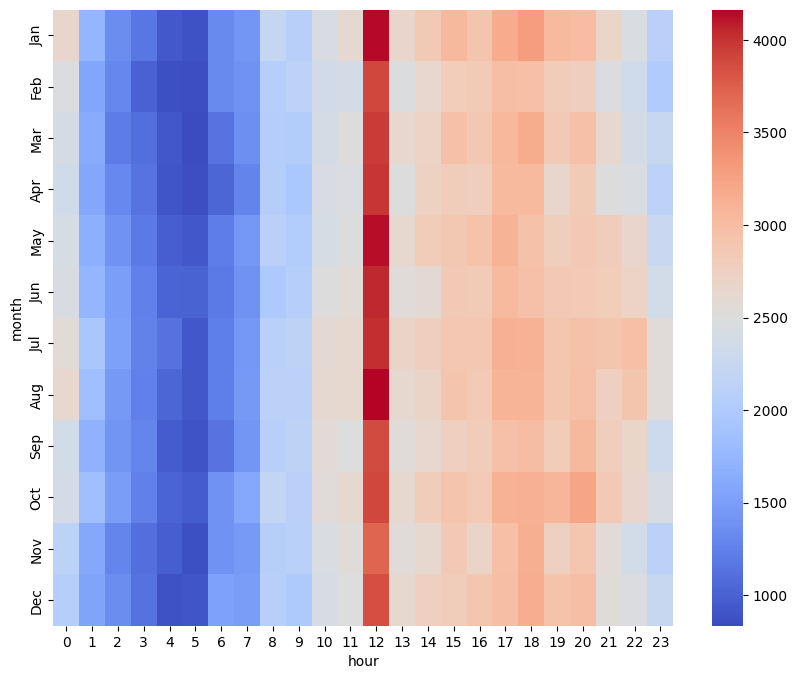

In [26]:
crimehours = lacrime.groupby(['month','hour'])['DR_NO'].count().reset_index()
crimehoursheat = crimehours.pivot(index = 'month', columns = 'hour', values = 'DR_NO')
crimehoursheat.index = crimehoursheat.index.map(lambda x: calendar.month_abbr[x])
fig,ax = plt.subplots(figsize=(10,8))
ax = sns.heatmap(crimehoursheat,cmap='coolwarm', ax = ax)
# implies heavily that a lot of data doesn't have a time, or officers are just putting in 0:00 or something along those lines

#### 3.2.5 Analysis of Area
Looking at area as categorical data, there are obvious hot spots of crime. We removed the outliers from displaying in the box and whisker plot for now. We can cross reference this with latitude/longitudinal data to see which areas of each neighborhood are potentially the most dangerous or highest crime. Neighborhoods also have unique demographics, which could lend insight into police treatment. We should also look at the type of crime by area, perhaps "safer" areas could contradictorily be safe because of heavier policing and more minor crimes being charged.

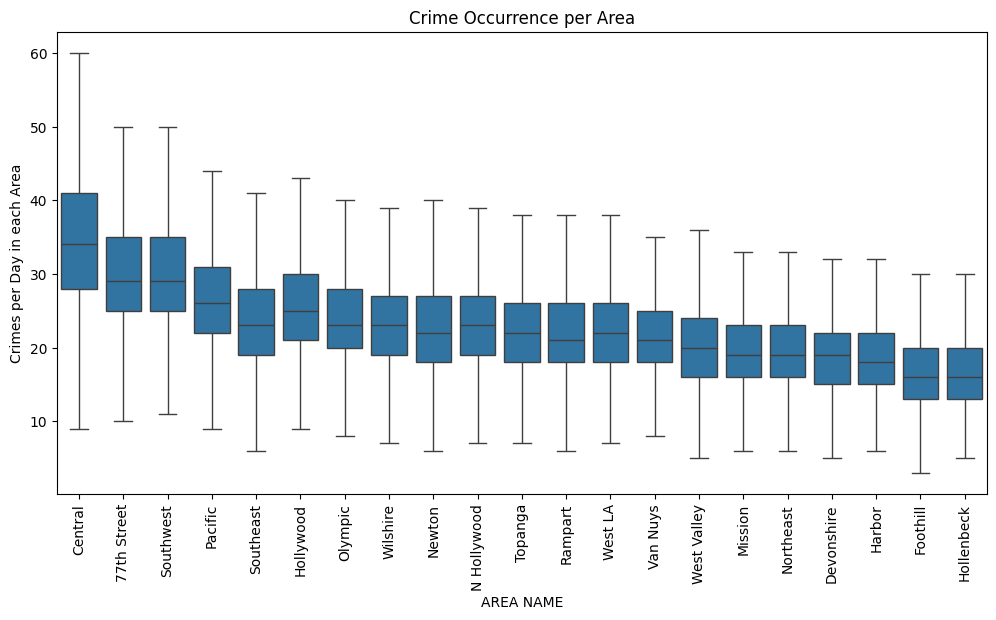

In [27]:
plt.figure(figsize = (12,6))
area_order = lacrime.groupby('AREA NAME')['area_score'].mean().sort_values(ascending=False).index
sns.boxplot(data=lacrime, x='AREA NAME', y='area_score', order = area_order, showfliers = False)
# sns.boxplot(data=lacrime, x='AREA NAME', y='area_score', showfliers = True)
# sns.boxplot(data=lacrime[lacrime['AREA NAME'] != 'Wilshire'], x='AREA NAME', y='area_score')
plt.xticks(rotation=90)
plt.title("Crime Occurrence per Area")
plt.ylabel("Crimes per Day in each Area")
plt.show()


#### 3.2.6 Crime severity vs number of charges
Our easiest measure for crime severity is just categorization of weapon usage and Part 1 vs Part 2 crimes. Here we can see a relationship between the number of crime codes and the severity of the crime charged. Part 1 and Part 2 crimes encompass crime codes as well, Part 1 being the more serious crimes like violent assault, etc. We could attempt to simply parse the text for certain keywords and revisit severity that way. 

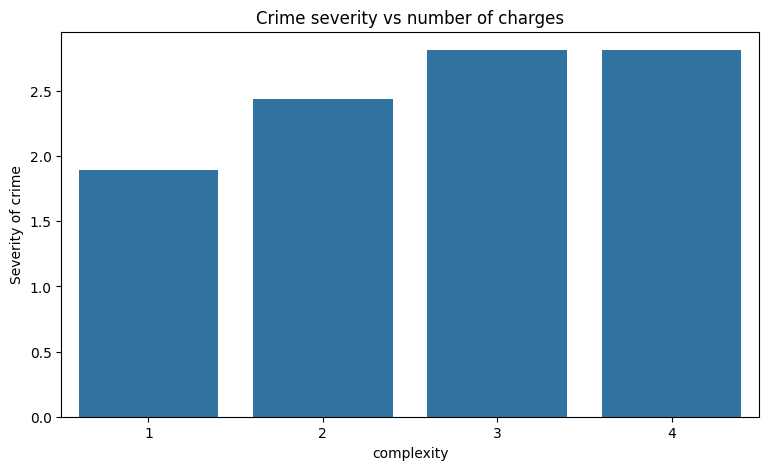

In [28]:
plt.figure(figsize=(9,5))
sns.barplot(data=lacrime, x = 'complexity', y = 'severity', errorbar = None)
plt.title("Crime severity vs number of charges")
plt.ylabel("Severity of crime")
plt.show()

#### 3.2.7 Correlation matrix
There are no obvious trends from our correlation matrix, which is probably to be expected with the coarse treatment of our variables. Severity is binned in 3, complexity is also binned in 4. There are no clear linear relationships between these variables, so we can immediately conclude that single variable OLS is probably out of the picture. However, there is potential in looking at crime complexity against severity, but as stated above, these large bins would require more finesse in understanding.

<Axes: >

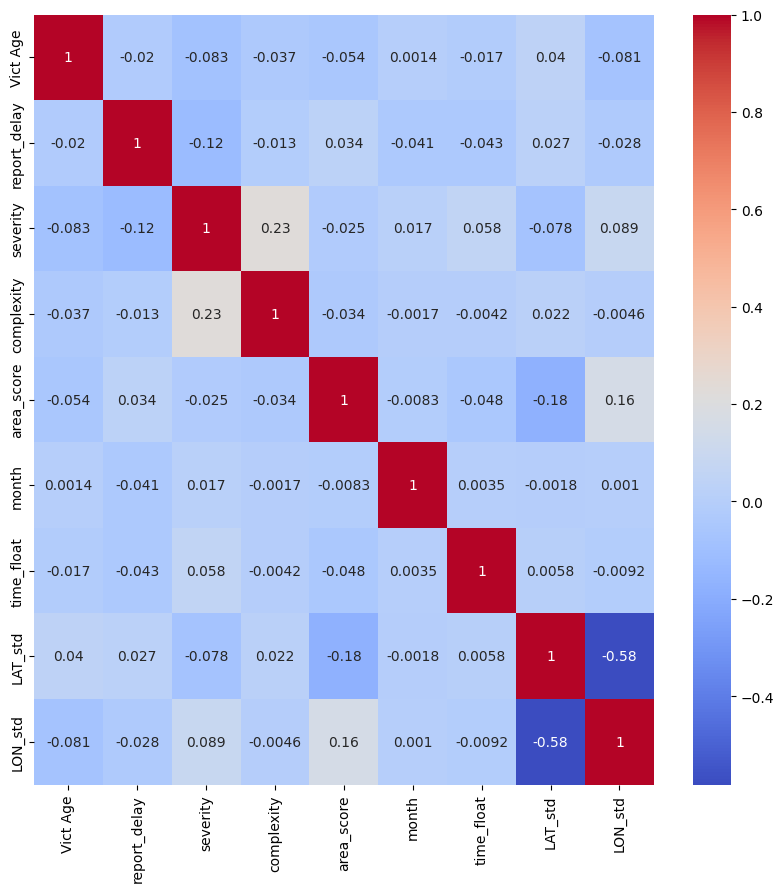

In [29]:
corrcols = [
    'Vict Age',
    'report_delay',
    'severity',
    'complexity',
    'area_score',
    'month',
    'time_float',
    'LAT_std',
    'LON_std'
]
corr_mat = lacrime[lacrime['loc_missing']!= 1][corrcols].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_mat,annot=True,cmap ='coolwarm')

### 3.3 Data issues
Just from a very cursory analysis of the data, there are several issues that we will have to deal with, not limited to:
* Reporting issues - There are 0s in latitude, longitude, age. There is a clear trend in crimes occurring in the beginning of the month, way more than is to be expected. In addition, there is a clear dropoff in crimes in 2024/2025 that does seems artificial. In dealing with this data, we will need to understand all the reporting errors that can occur and clean more thoroughly.
* This may have been wishful thinking, but our only strong correlations area in latitude and longitude (which makes sense based on the shape of Los Angeles stretching northwest to southeast along the coast of Southern California).  
* The data is messy overall and potentially incomplete: Crime code descriptions and weapon descriptions are in text, which will require some extraction. A lot of the codes will require external sources, such as Vict Descent and Mocodes (modus operandi), which have been loaded in, but there may be others required. We have already attempted clean up and limited the date range (seeing a huge drop off in 2025), but there are more issues in the time series data that we must take care of.

### 3.4 Basic analytics

#### 3.4.1 Severity
We run a simple linear regression. The linear regression actually shows p-values that imply that nearly all of our variables are significant. However, their magnitude is quite low, and our R^2 of .303 is poor. The model could potentially be refined by adding in more variables (we only used 6 of 27).

In [30]:
df = lacrime.dropna(subset=['severity', 'report_delay', 'weapon_cd', 'hour', 'complexity', 'AREA', 'vDescent'])

model = smf.ols(
    formula='severity ~ report_delay + weapon_cd + hour + complexity + C(AREA) + C(vDescent)',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               severity   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     6932.
Date:                Tue, 16 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:31:16   Log-Likelihood:            -5.3637e+05
No. Observations:              658639   AIC:                         1.073e+06
Df Residuals:                  658595   BIC:                         1.073e+06
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

#### Fitting SARIMAX to time series data
It seems plausible that crime follows certain seaonal and daily trends. For example, whether or not people are commuting for work could contribute to traffic violations. We will do a first differencing and a seasonal differencing to see if we can get a stationary data set, and then apply a simple SARIMAX to the data. 

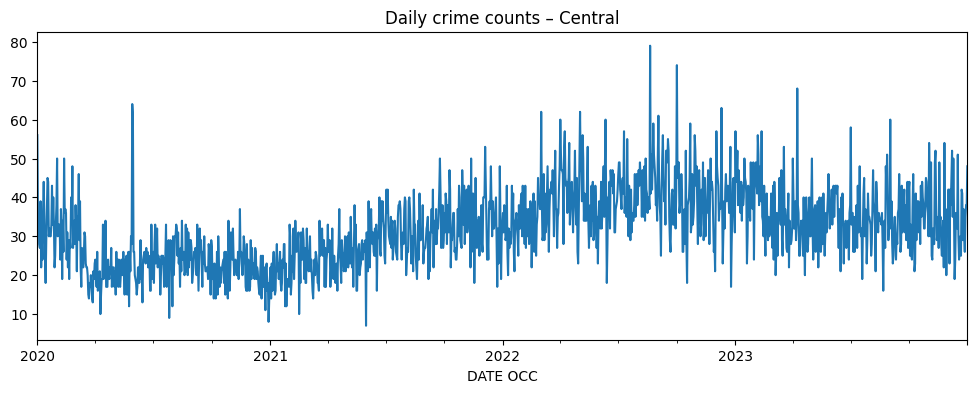

ADF p-value: 0.2478


In [31]:
daily_area = lacrime.groupby(['DATE OCC', 'AREA']).size().reset_index(name='crime_count')

## use Central as example (highest mean)
area_name = 'Central'
# area_name = 'ff'
ts = daily_area[daily_area['AREA'] == area_name].set_index('DATE OCC').sort_index()


ts['crime_count'].plot(figsize=(12,4), title="Daily crime counts – Central",)
plt.show()

adf_stat, pvalue, *_ = adfuller(ts['crime_count'])
print(f"ADF p-value: {pvalue:.4f}")


Our ADF p-value shows that our data is not stationary, and requires differencing.    

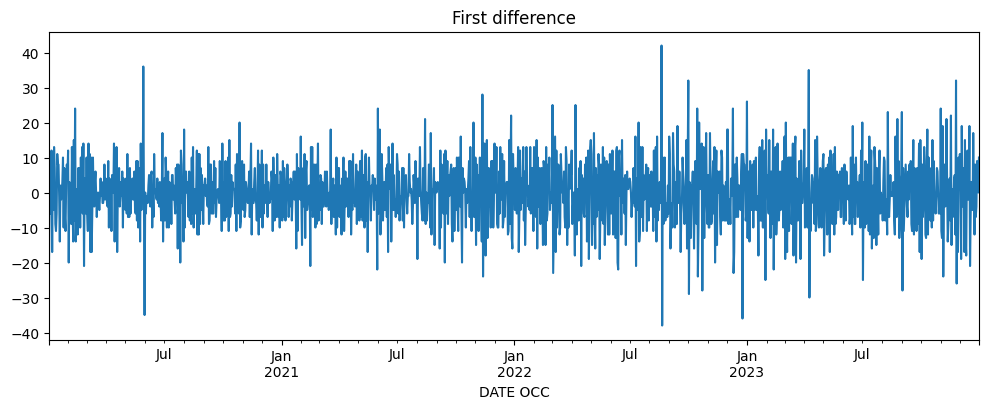

ADF after diff: 5.932506164117513e-27


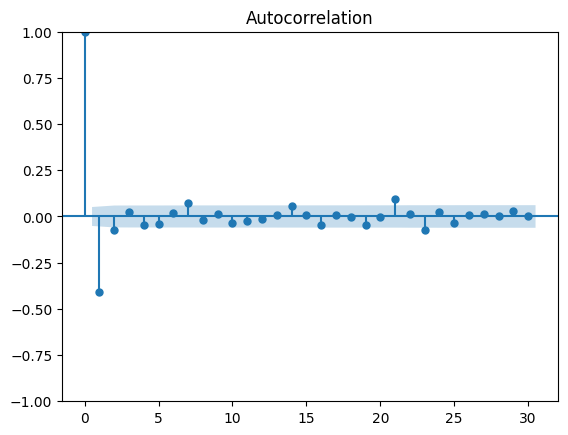

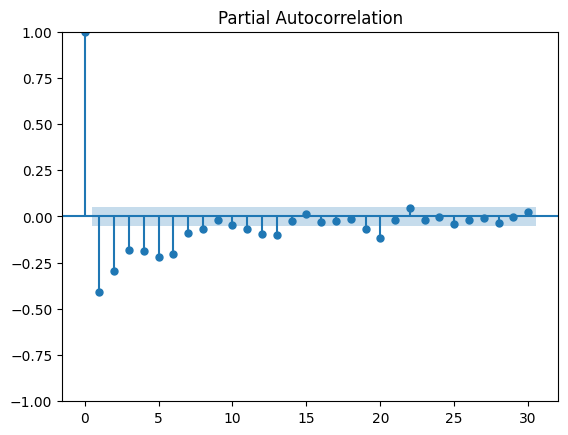

In [32]:
ts['diff1'] = ts['crime_count'].diff()
ts['diff1'].dropna().plot(figsize=(12,4), title="First difference")
plt.show()

print("ADF after diff:", adfuller(ts['diff1'].dropna())[1])

plot_acf(ts['diff1'].dropna(), lags = 30)
plt.show()
plot_pacf(ts['diff1'].dropna(), lags = 30)
plt.show()



After first differencing, we still observe what looks like a sine wave with peaks around multiples of 7 (which makes sense). The PACF implies we may be over-differencing as it corrects itself over the first 15 days. We will apply one more differencing:

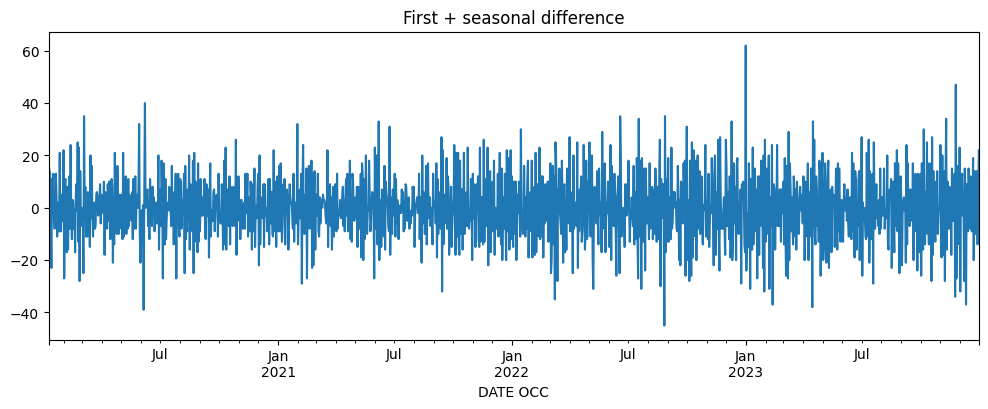

ADF after seasonal diff: 1.3004037457169626e-28


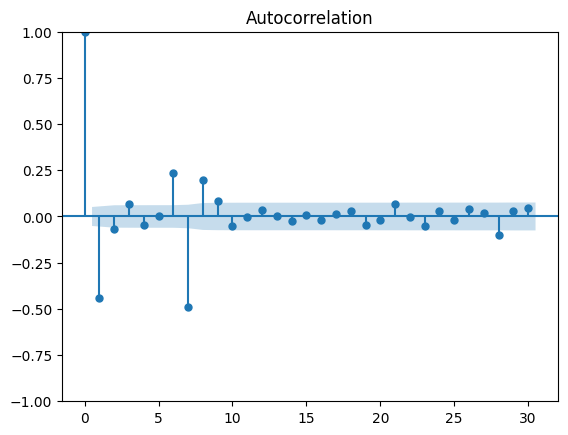

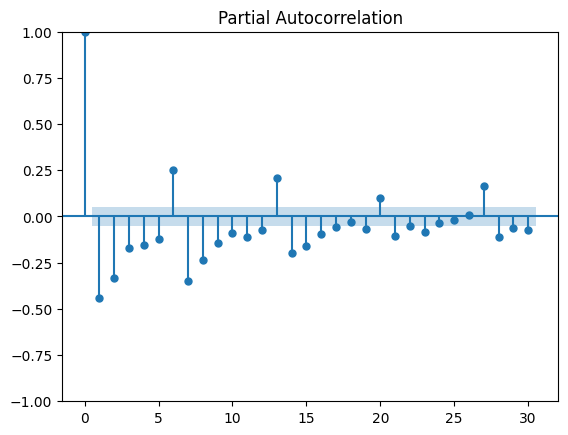

In [33]:
ts['diff_seasonal'] = ts['diff1'].diff(7)
ts['diff_seasonal'].dropna().plot(figsize=(12,4), title="First + seasonal difference")
plt.show()

print("ADF after seasonal diff:", adfuller(ts['diff_seasonal'].dropna())[1])

plot_acf(ts['diff_seasonal'].dropna(), lags = 30)
plt.show()
plot_pacf(ts['diff_seasonal'].dropna(), lags = 30)
plt.show()

Our initial data set failed the ADF test, implying it was non-stationary, but this was fixed with first differencing. We will stick with $(p, d, q) = (1, 1, 1)$. However, in seasonal differencing, we saw negative spikes at 1 in both the ACF and PACF graph. The PACF graph in particular shows oscillation, it is reverting to mean through the week and there is no weekly trend. This implies over-differencing, so we will let $D = 0$ and $(P, D, Q, s) = (1, 0, 1, 7)$.

/Users/alanxu/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/alanxu/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                       crime_count   No. Observations:                 1461
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -4905.780
Date:                           Tue, 16 Dec 2025   AIC                           9821.560
Time:                                   22:31:18   BIC                           9847.960
Sample:                               01-01-2020   HQIC                          9831.411
                                    - 12-31-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1083      0.026      4.125      0.000       0.057       0.160
ma.L1         -0.9361      0.010    -93.019

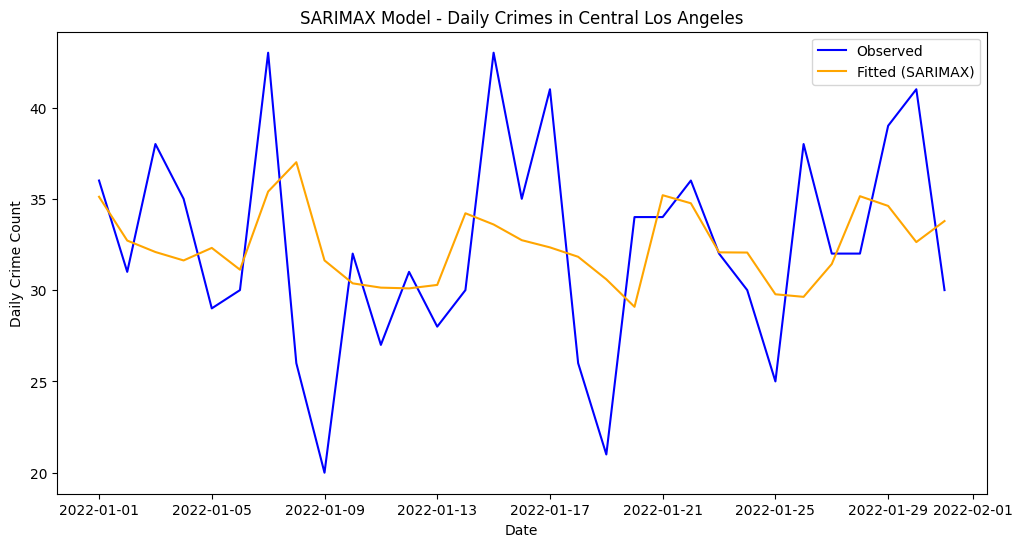

In [34]:
model = SARIMAX(
    ts['crime_count'],
    order=(1,1,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
ts.index = pd.to_datetime(ts.index)
ts = ts.asfreq('D')

sarimax_result = model.fit(disp=False)
print(sarimax_result.summary())


ts['pred'] = sarimax_result.fittedvalues
ts_2022 = ts[(ts.index.year == 2022) & (ts.index.month == 1)]

plt.figure(figsize=(12,6))
plt.plot(ts_2022.index, ts_2022['crime_count'], label='Observed', color='blue')
plt.plot(ts_2022.index, ts_2022['pred'], label='Fitted (SARIMAX)', color='orange')
plt.title(f"SARIMAX Model - Daily Crimes in {area_name} Los Angeles")
plt.xlabel('Date')
plt.ylabel('Daily Crime Count')
plt.legend()
plt.show()


Looking at our predicted values, there is a decent fit when just restricted to January 2022. The `ar.L1` coefficient tells us that there is an 11% persistence in daily changes, with high certainty. The `ma.L1` coefficient is nearly negative 1, telling us that noise is generally corrected each day. `ar.S.L7` is approximately 1, implying a strong relationship with between each week, confirming our hypothesis of weekly crime trends. Lastly, the `ma.S.L7` coefficient had such a high P value that it may be overparametrization. 

Our overall model behavior still has unaccounted for biases: heteroskedasticity is high so our residuals splay. We have a high p-value in the Ljung-Box test, so we fail to reject the null of no autocorrelation. This seems to fit intuition. Our JB test shows residuals are non-normal, which is not unexpected. Ultimately our log-likelihood of -6e3 indicates a reasonable fit given the amount of data present. Our conclusion here is that SARIMAX captured some of the short term and weekly patterns, but we would need to do more data cleaning and refinement, especially dealing with the residual heteroskedasticity and lack of normality.

## 4 Models and Results

### 4.1: Did violent crime increase or decrease after 2020? If there was a change, when did it happen?

This is a relatively simple and obvious question. COVID-19 lockdowns kept people at home, preventing them from committing (and also reporting) several types of crimes. After the lockdowns were lifted, crime would gradually increase , but perhaps not to pre-COVID levels. Our data set starts January 2020, well after the first stirrings in the news about the disease had taken place. The bulk of our first year of data takes place during lockdowns. When did the crime rate start to increase? How were different areas affected?

First, let's consider which crimes to look at. Severity is a score assigned by whether the crime was Part 1 or Part 2 (with Part 1 being more severe) and whether or not a weapon was involved. Severity 3 crimes are the most serious crimes, while severity 2 crimes are the most abundant, being either a Part 1 crime with no weapon involved, or a Part 2 crime with a weapon coded.

In [35]:
lacrime['severity'].value_counts()

severity
2    370573
1    164498
3    123597
Name: count, dtype: int64

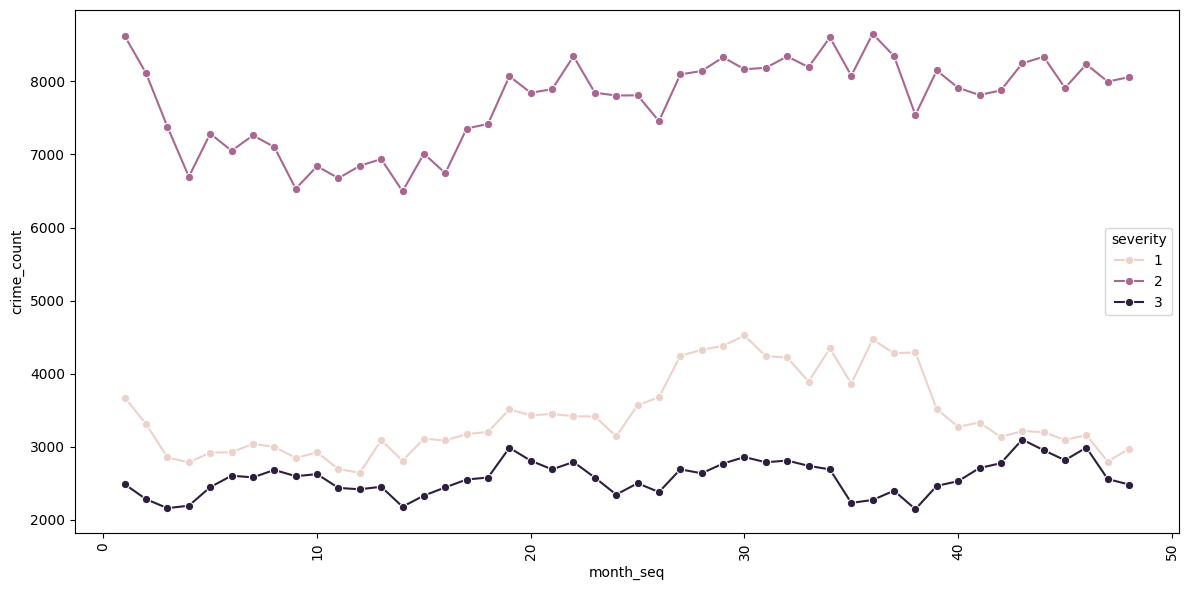

In [36]:
monthly_plot = lacrime.groupby([pd.Grouper(key = 'month_seq'), 'severity']).size().reset_index(name = 'crime_count')
fig,ax = plt.subplots(figsize = (12,6))
sns.lineplot(data = monthly_plot, x = 'month_seq', y = 'crime_count', hue = 'severity',marker = 'o',  ax = ax)

plt.setp(ax.get_xticklabels(), rotation = 90)

plt.tight_layout()

A basic look at this chart shows an increasing trend. It makes intuitive sense, given the lockdown period prevented people from being outside and reporting crimes. Let's see if we can understand this more clearly, and perhaps find a split point when the crime rate rose back up after lockdown. We see a clear increase in crime for Type 1 and 2, and perhaps a more subtle rise for Type 3 crimes.

#### 4.1.1 Severity over time GLM 
First, let us try to analyze the data with a simple generalized linear model. 

In [37]:
# fit a poisson GLM model based solely on sequential month to check if crime counts are increasing or decreasing
def sev_model(sev_score):
    n = sev_score
    sev = monthly_plot[monthly_plot['severity'] == n].copy() ## create a copy of the data set

    # sev['log_crime_count'] = np.log(sev['crime_count']) # unused for now (2025-12-7)
    model_sev = smf.glm("crime_count ~ month_seq", data = sev, family = sm.families.Poisson()).fit()
    # model_sev.summary()
    return model_sev, sev

def sev_model_fit(model_sev, sev, sev_score):
    sev['expected_count'] = np.exp(model_sev.params['Intercept'] + model_sev.params['month_seq'] * sev['month_seq']) # fit model predictions
    fig,ax = plt.subplots(figsize=(12, 6))

    # plot observed data and then predicted data
    ax.plot(sev['month_seq'], sev['crime_count'], marker ='o', label = 'Observed')
    ax.plot(sev['month_seq'], sev['expected_count'], color = 'red', linestyle = '--', label = 'GLM Fit')
    
    ax.set_xlabel('Sequential month')
    ax.set_ylabel(f'Severity {sev_score} crime count')
    ax.set_title(f'Severity {sev_score} crime count over time')
    plt.xticks(rotation = 90)
    plt.tight_layout()
    plt.show



In [38]:
model_sev3, sev3 = sev_model(3)
model_sev3.summary()
# sev_model_fit(model_sev3, sev3, 3)

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            crime_count   No. Observations:                   48
Model:                            GLM   Df Residuals:                       46
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -655.75
Date:                Tue, 16 Dec 2025   Deviance:                       846.51
Time:                        22:31:18   Pearson chi2:                     838.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9485
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.7930      0.006   1328.791      0.000       7.781       7.804
month_seq      0.0025      0.000     11.929      0.000       0.002       0.003
==============================================================================
"""

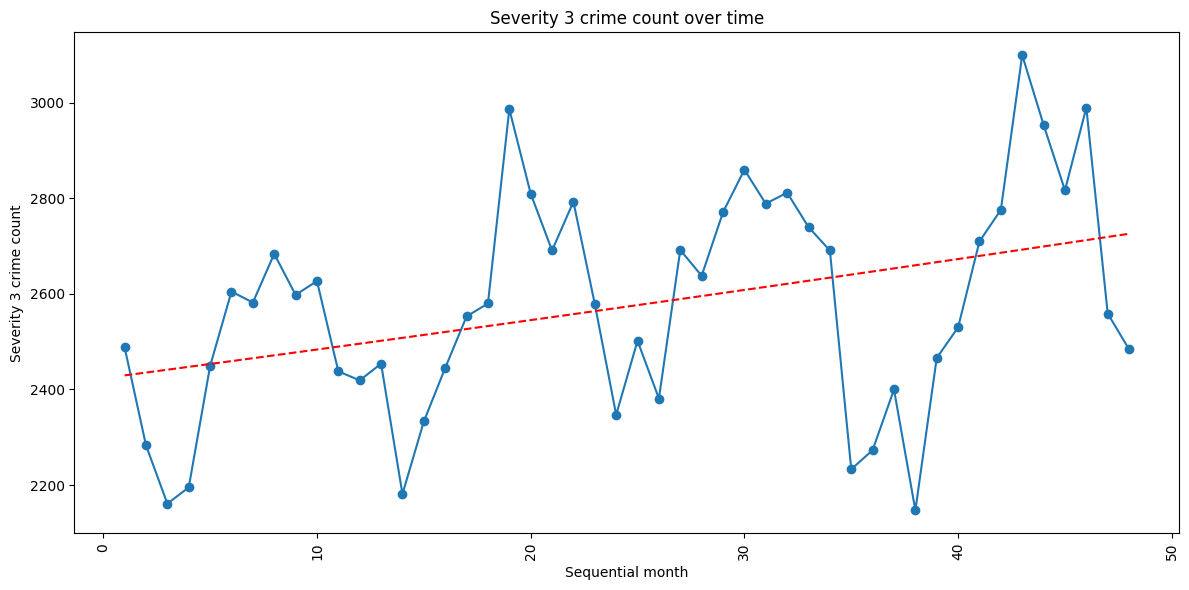

In [39]:
sev_model_fit(model_sev3, sev3, 3)

Our Poisson GLM shows a clear increasing trend, a statistically significant (although small) coefficient for `month_seq`. $e^{.0025} \approx 1.0025$ or a .25% increase, which translates to about 3% per year. Our p-value and z-score both show that the data is significant. We can conclusively answer that severe crime has increased since 2020. We don't however know the causes, population change, recordkeeping changes, etc. Let's apply the analysis to severity 1 and 2 crimes as well. 

In [40]:
model_sev2, sev2 = sev_model(2)
model_sev2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            crime_count   No. Observations:                   48
Model:                            GLM   Df Residuals:                       46
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -975.78
Date:                Tue, 16 Dec 2025   Deviance:                       1433.8
Time:                        22:31:18   Pearson chi2:                 1.45e+03
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.8671      0.003   2602.723      0.000       8.860       8.874
month_seq      0.0034      0.000     28.699      0.000       0.003       0.004
==============================================================================
"""

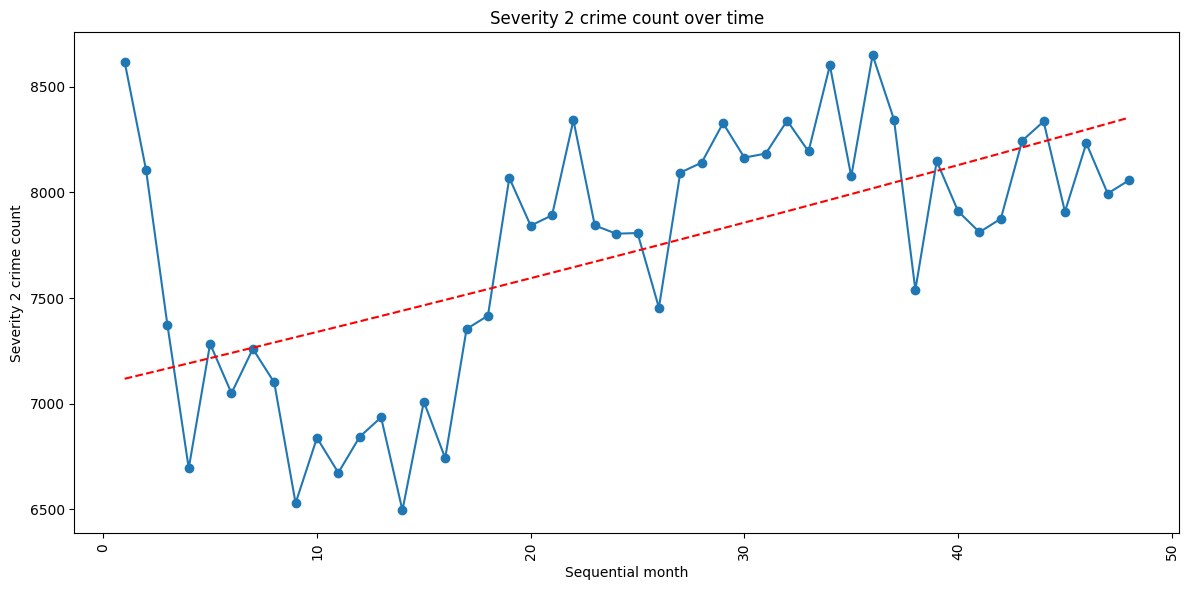

In [41]:
sev_model_fit(model_sev2, sev2, 2)

In [42]:
model_sev1, sev1 = sev_model(1)
model_sev1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            crime_count   No. Observations:                   48
Model:                            GLM   Df Residuals:                       46
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1947.4
Date:                Tue, 16 Dec 2025   Deviance:                       3416.5
Time:                        22:31:19   Pearson chi2:                 3.47e+03
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.0322      0.005   1562.132      0.000       8.022       8.042
month_seq      0.0043      0.000     24.156      0.000       0.004       0.005
==============================================================================
"""

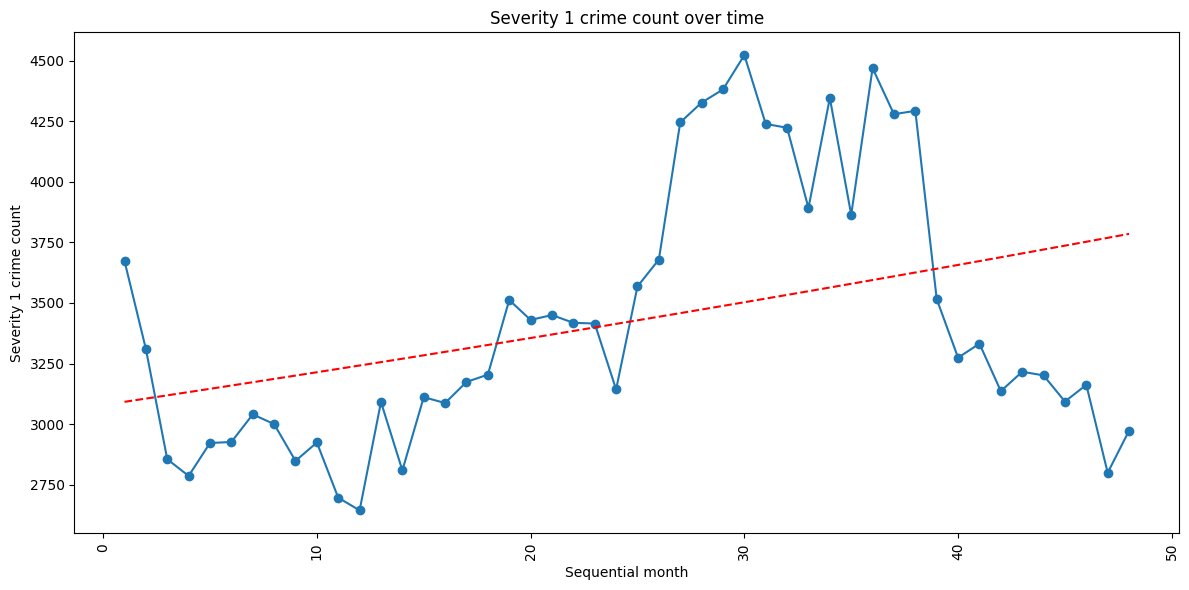

In [43]:
sev_model_fit(model_sev1, sev1, 1)

Initial conclusions and problems with this approach:

In severity 1 and 2 cases, we also see an increase with just a simple regression. However, when we investigate the graph of severity 1 crimes, there is a clear problem where the increase in crime looks temporary. Severity 2 looks like it had the most drastic increase. By inspecting log likelihoods, we find the most convincing model from severity 3, with decreasing effectiveness as severity decreases. A quick inspection below shows that Severity 1 crimes are dominated by identity theft, vandalism (both felony and misdemeanor), trespassing, and violations of orders, not necessarily violent crimes. We will ignore these for now and focus on violent crimes.

We are limited in our ability to add more variables to the model, because crime count, severity, and complexity are all interlinked. Severity and complexity are the properties of the crimes being committed and, as predictors, are functionally useless. We are somewhat limited in our data set, so we will explore another avenue.

#### 4.1.2 Switchpoint in severity 2 and 3 crimes

Let's instead apply what we learned in the mine accident study to see if we can find a switch point in Severity 2 and 3 crimes.

In [44]:
lacrime[lacrime['severity'] == 1][['severity', 'Crm Cd Desc']].groupby('Crm Cd Desc', dropna = False).count().sort_values(by = 'severity', ascending = False).head(10).reset_index()

,Crm Cd Desc,severity
0,THEFT OF IDENTITY,55184
1,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",36429
2,VANDALISM - MISDEAMEANOR ($399 OR UNDER),16354
3,VIOLATION OF RESTRAINING ORDER,10169
4,TRESPASSING,7298
5,"LETTERS, LEWD - TELEPHONE CALLS, LEWD",6715
6,VIOLATION OF COURT ORDER,5570
7,"BUNCO, GRAND THEFT",5411
8,OTHER MISCELLANEOUS CRIME,3608
9,CONTEMPT OF COURT,2270


In [45]:
lacrime[lacrime['severity'] == 2][['severity', 'Crm Cd Desc']].groupby('Crm Cd Desc', dropna = False).count().sort_values(by = 'severity', ascending = False).head(10).reset_index()

,Crm Cd Desc,severity
0,BATTERY - SIMPLE ASSAULT,68535
1,BURGLARY FROM VEHICLE,49519
2,INTIMATE PARTNER - SIMPLE ASSAULT,43180
3,THEFT PLAIN - PETTY ($950 & UNDER),37866
4,BURGLARY,32291
5,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,29412
6,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",22517
7,CRIMINAL THREATS - NO WEAPON DISPLAYED,17246
8,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),14384
9,SHOPLIFTING - PETTY THEFT ($950 & UNDER),7030


Severity 1 crimes are generally petty theft, or violation of court orders or decorum. We'll ignore them for now and pursue more serious crimes. Instead of taking the monthly number of crimes, let's split it up into weekly crimes. 

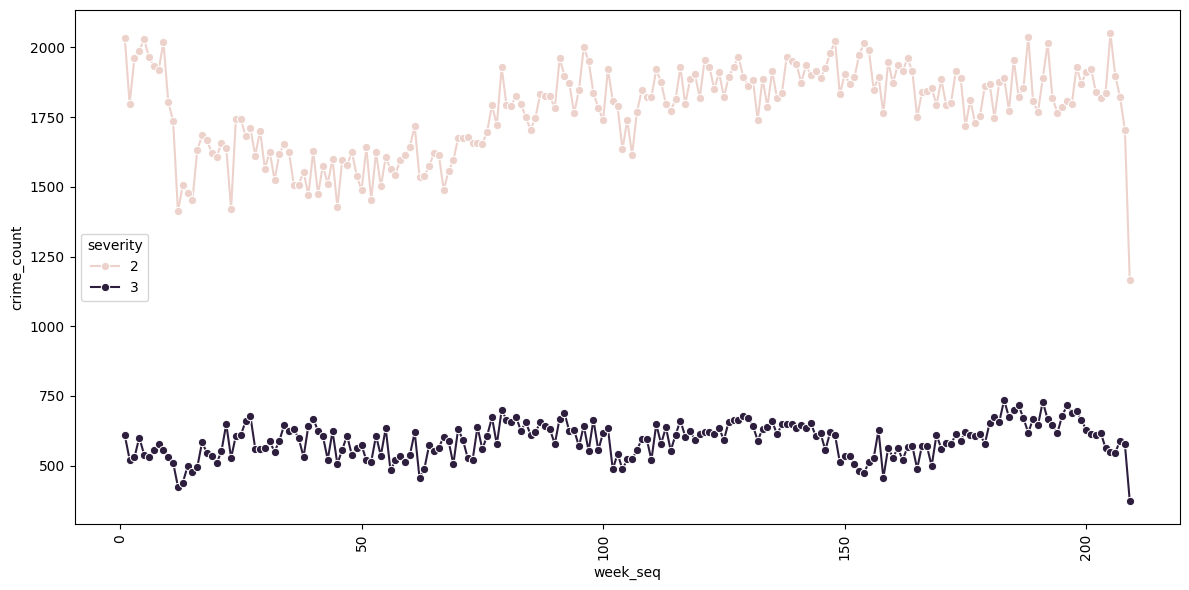

In [46]:
weekly_plot = lacrime.groupby([pd.Grouper(key = 'week_seq'), 'severity']).size().reset_index(name = 'crime_count')
fig,ax = plt.subplots(figsize = (12,6))
sns.lineplot(data = weekly_plot[weekly_plot['severity'] != 1], x = 'week_seq', y = 'crime_count', hue = 'severity',marker = 'o',  ax = ax)

plt.setp(ax.get_xticklabels(), rotation = 90)

plt.tight_layout()

Just based on the sheer amount of crimes committed, we will proceed with Severity 2 analysis first.

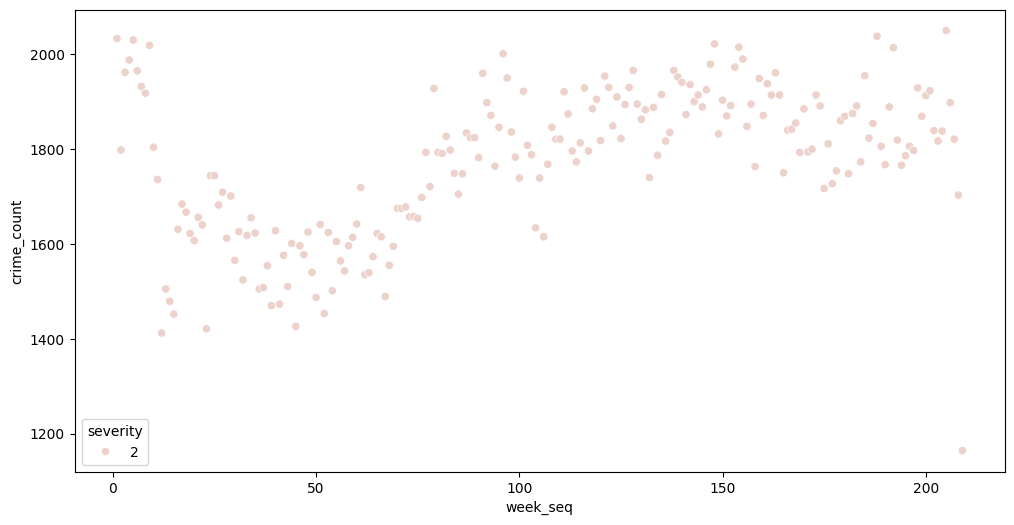

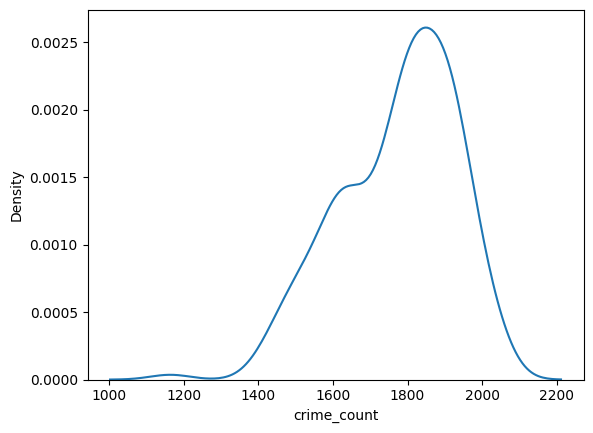

In [47]:
bayes_weekly_plot = weekly_plot[weekly_plot['severity'].isin([2])]

fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(data = bayes_weekly_plot, x = 'week_seq', y = 'crime_count', hue = 'severity', marker = 'o', ax = ax)
plt.show()
sns.kdeplot(x = 'crime_count', data = bayes_weekly_plot)
plt.show()


In [48]:
print("Mean weekly crime count = {0:4.2f}".format(np.mean(bayes_weekly_plot.loc[:, 'crime_count'])))
print("Mean weekly crime count before 108 = {0:4.2f}".format(np.mean(bayes_weekly_plot.loc[bayes_weekly_plot['week_seq'] < 109, 'crime_count'])))
print("Mean weekly crime count after 108 = {0:4.2f}".format(np.mean(bayes_weekly_plot.loc[bayes_weekly_plot['week_seq'] >= 109, 'crime_count'])))

Mean weekly crime count = 1773.08
Mean weekly crime count before 108 = 1689.31
Mean weekly crime count after 108 = 1862.65


Sampling: [crimes, early_rate, late_rate, switchpoint]


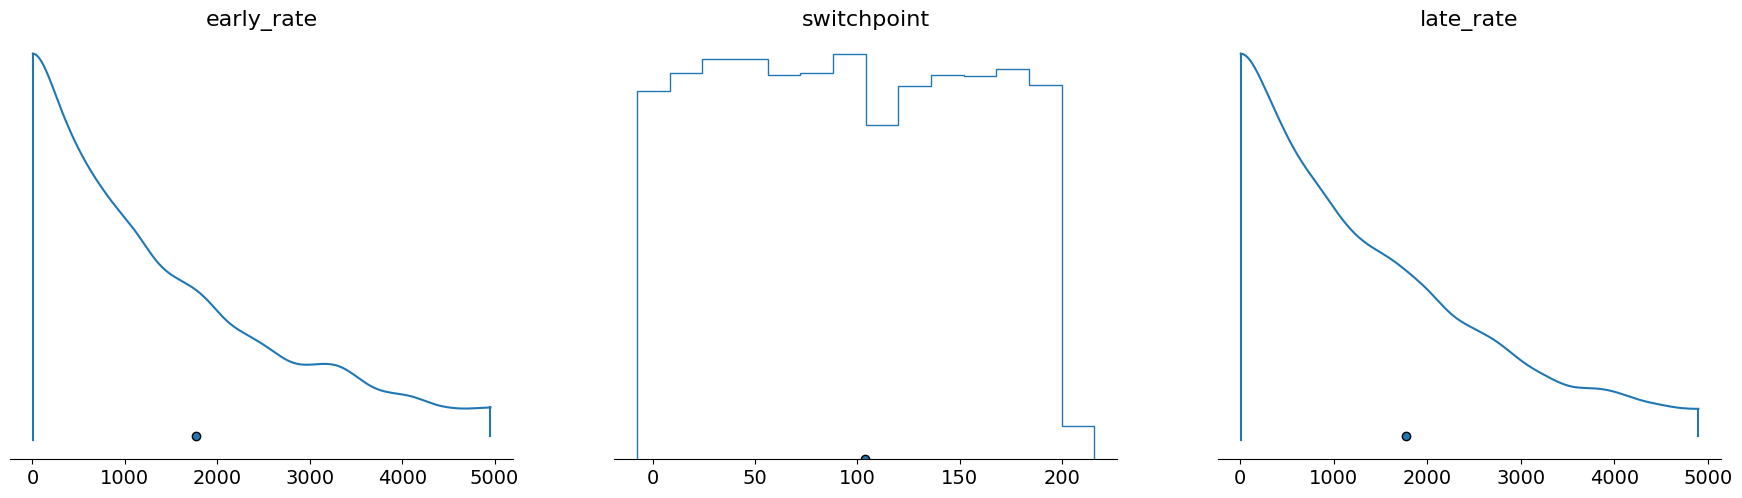

In [49]:
week_seq = bayes_weekly_plot['week_seq'].values
crime_count = bayes_weekly_plot['crime_count'].values

with pymc.Model() as sev_bayes:
    switchpoint = pymc.DiscreteUniform("switchpoint", lower=0, upper = len(crime_count)-1)
    n_for_exp = np.mean(bayes_weekly_plot.loc[:, 'crime_count'])
    early_rate = pymc.Exponential("early_rate", 1/n_for_exp)
    late_rate = pymc.Exponential("late_rate", 1/n_for_exp) ## pymc exponential function is inverse

    rate = pymc.math.switch(week_seq < switchpoint, early_rate, late_rate)

    sev2crimes = pymc.Poisson("crimes", rate, observed = bayes_weekly_plot['crime_count'])
    
with sev_bayes:
    prior_checks = pymc.sample_prior_predictive(samples = 5000)
prior_checks.keys()

_ = az.plot_density(prior_checks, group = 'prior')

Although we assume a discrete switchpoint, our work with the mine disasters shows that we can still use the NUTS method.

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [early_rate, late_rate]
>Metropolis: [switchpoint]


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 3 seconds.


array([[<Axes: title={'center': 'switchpoint'}>,
        <Axes: title={'center': 'switchpoint'}>],
       [<Axes: title={'center': 'early_rate'}>,
        <Axes: title={'center': 'early_rate'}>],
       [<Axes: title={'center': 'late_rate'}>,
        <Axes: title={'center': 'late_rate'}>]], dtype=object)

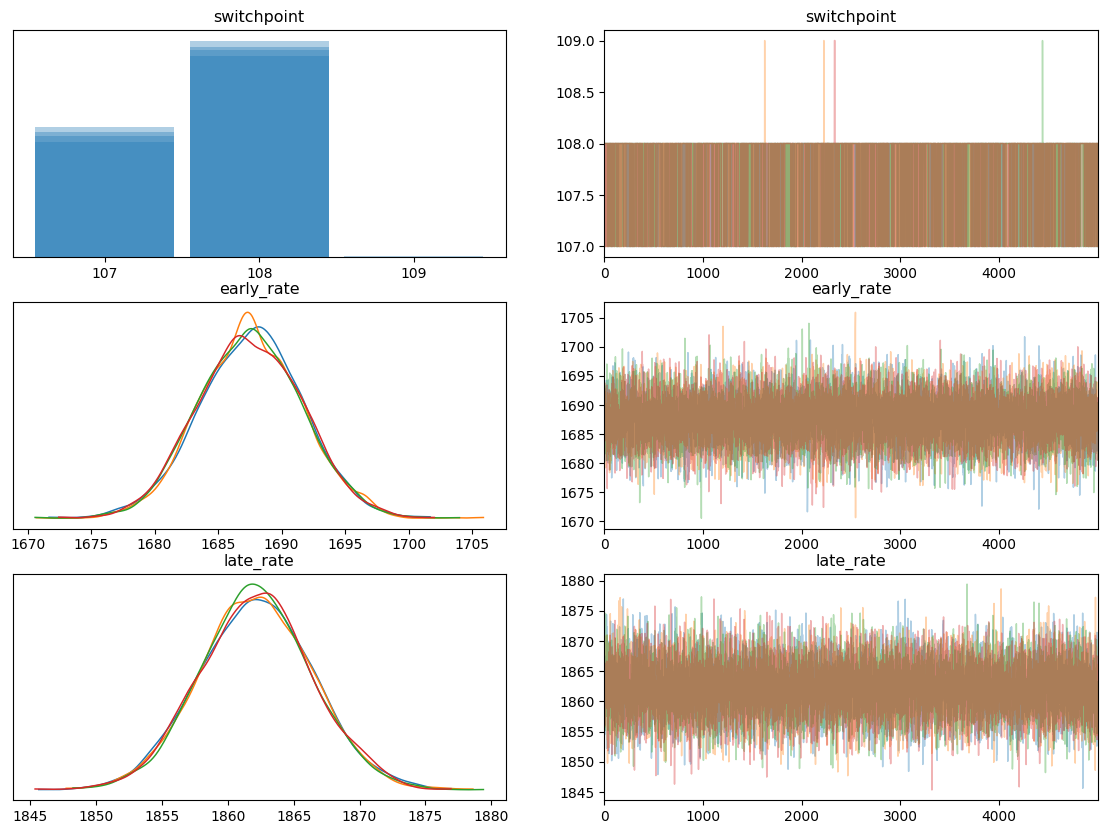

In [50]:
RNDSEED = 5555
with sev_bayes:
    sev_samples = pymc.sample(draws = 5000, return_inferencedata = True, step = [pymc.NUTS(target_accept=0.95, max_treedepth=60)], random_seed = RNDSEED)
az.plot_trace(sev_samples, compact=False, figsize = (14,10))


             mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
switchpoint      0.007    0.005    4499.0    4007.0    1.0
early_rate       0.035    0.025   13100.0   11899.0    1.0
late_rate        0.037    0.026   13624.0   12403.0    1.0


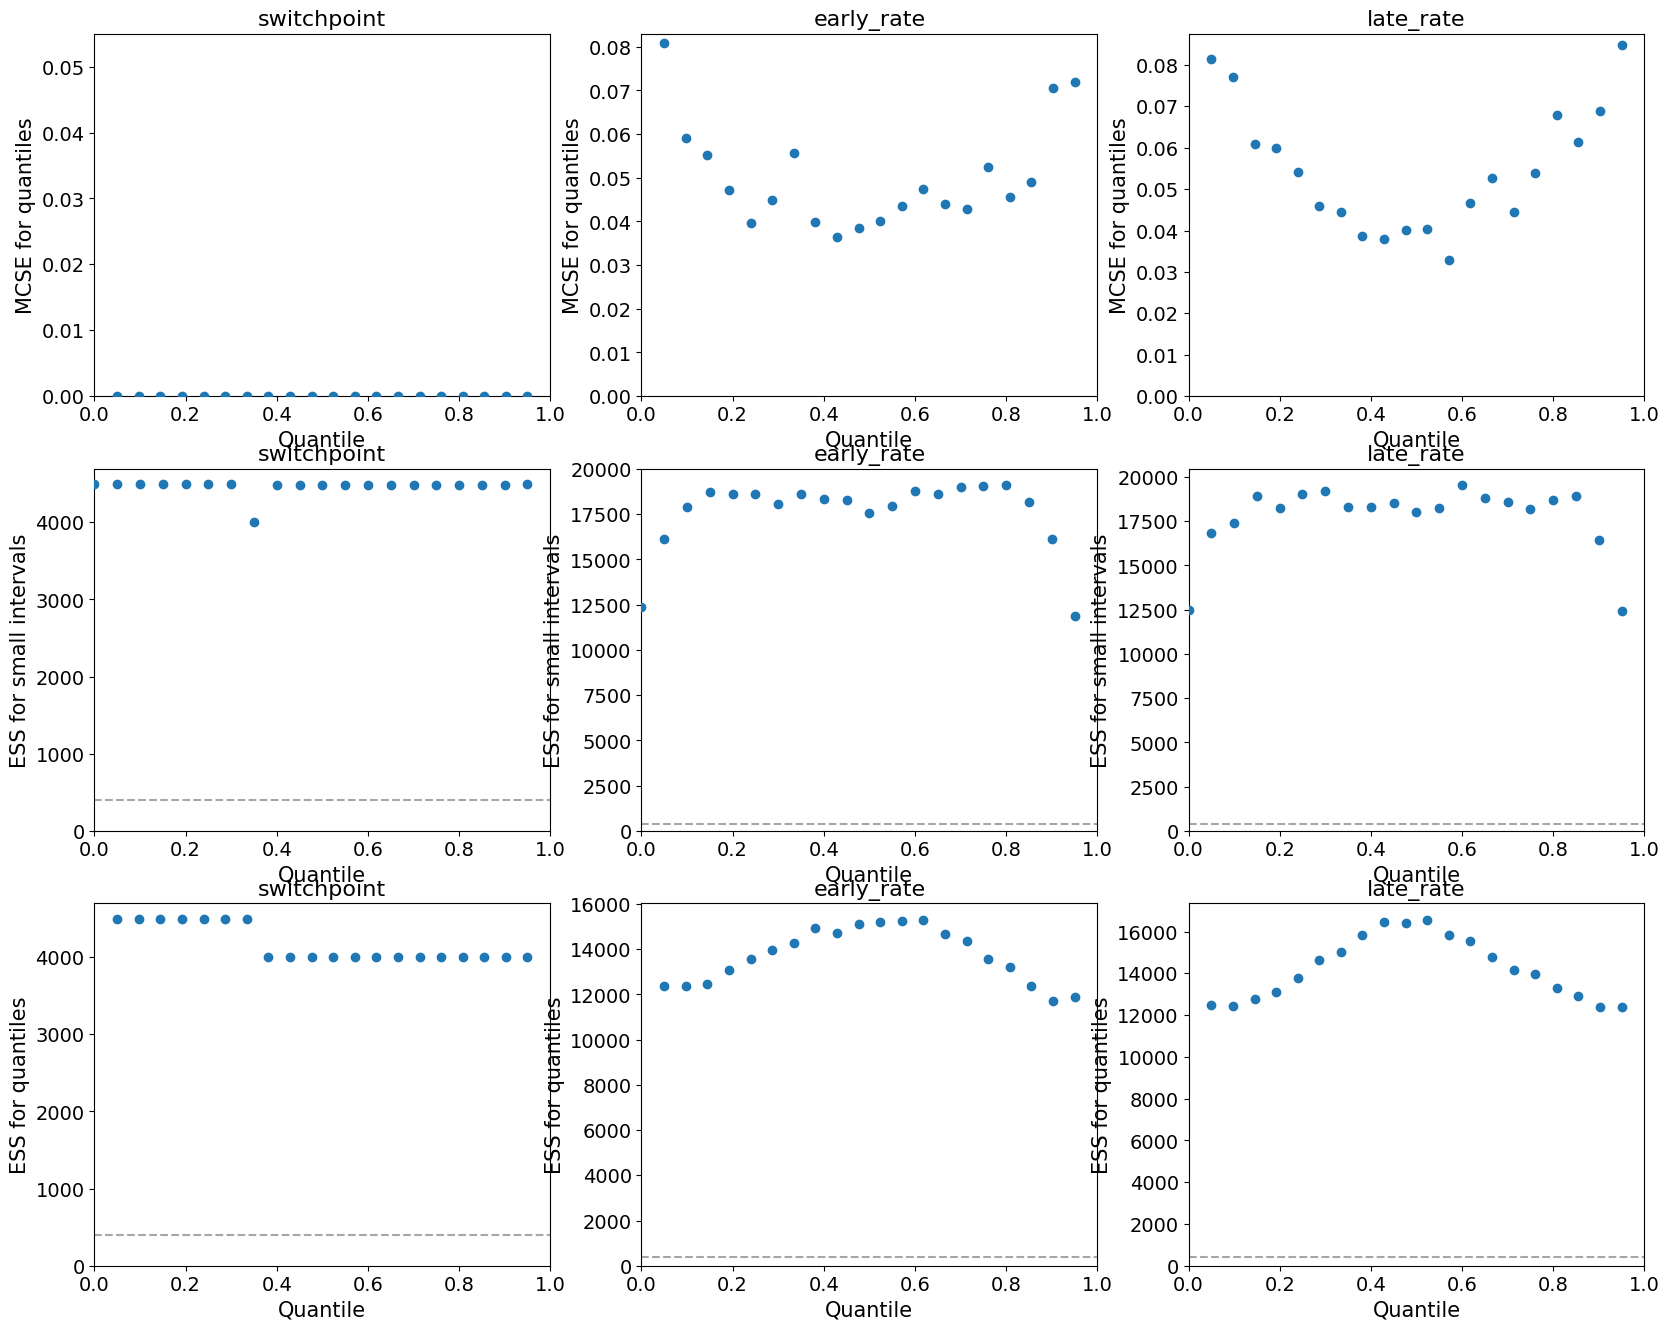

In [51]:
print(az.summary(sev_samples, kind = "diagnostics"))

_,ax = plt.subplots(3,3, figsize=(20,16))
az.plot_mcse(sev_samples, ax=ax[0])
az.plot_ess(sev_samples, kind="local", ax=ax[1]);
az.plot_ess(sev_samples, kind="quantile", ax=ax[2]);

Although our results weren't as clean as the mine example, we did see a significant difference. Switchpoint is locked onto weeks 108, which is late January 2022. Our ESS, MCSE, all pretty much point to certainty. Early and late rate metrics do have decent confidence. In quantiles, our tails had a higher MCSE as expected. Although these absolute values seem small relative to our scale of around 1800 weekly crimes.

ESS is very high for all samples. Overall our MCMC method is fine, though we will explore some problems with the distributions later.

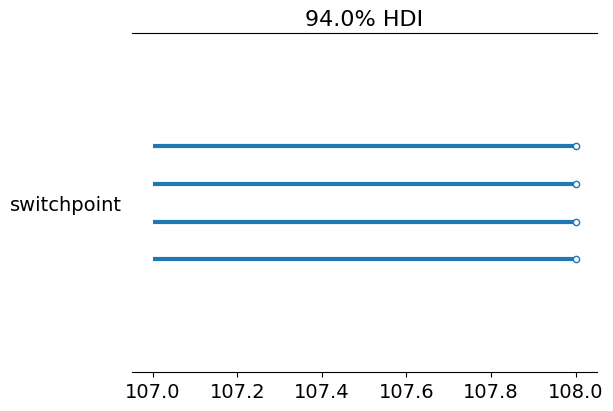

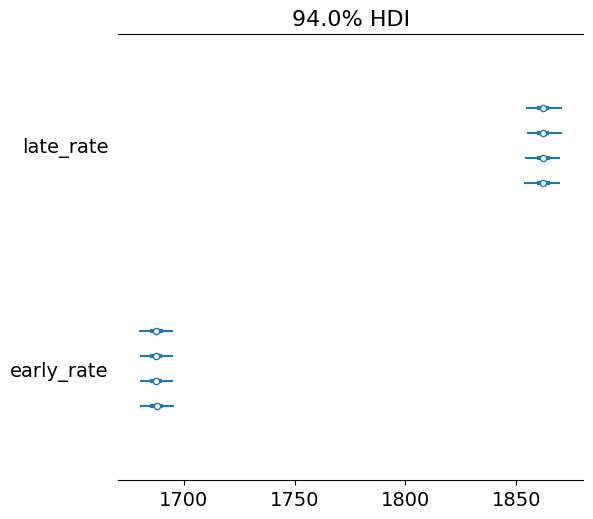

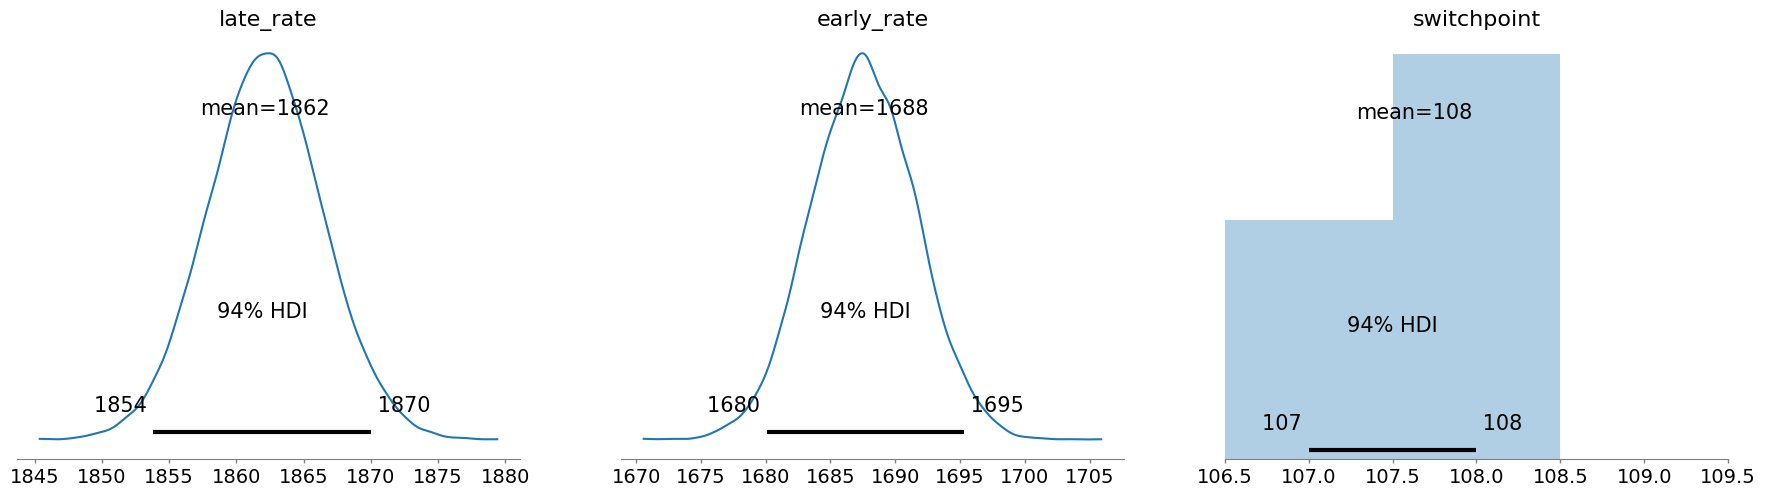

In [52]:
az.plot_forest(sev_samples, var_names = 'switchpoint')
az.plot_forest(sev_samples, var_names=['late_rate', 'early_rate']);
plt.show()
az.plot_posterior(sev_samples, var_names=['late_rate', 'early_rate', 'switchpoint']); 
plt.show()

Our difference in crime rate is significant, and the MCMC model seems locked onto week 108, which is approximately late January 2022, about 2 years after. However, let's take a look at the distributions.

Sampling: [crimes]


<Axes: xlabel='crimes'>

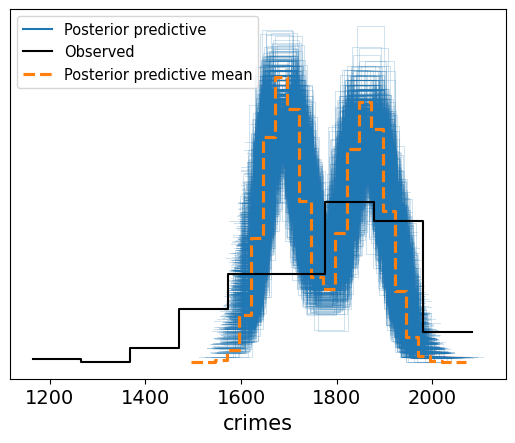

In [53]:
early_mask = bayes_weekly_plot['week_seq'] < 108
late_mask = bayes_weekly_plot['week_seq'] >= 108

with sev_bayes:
    pymc.sample_posterior_predictive(sev_samples, extend_inferencedata = True)
az.plot_ppc(sev_samples, num_pp_samples=1000)

Our prediction has two large peaks. The late rate fit looks OK, but the peak is too tall. The late rate variance is underestimated. On the other hand, the early rate is actually a bad fit. We will take a closer look at the early rate in subsequent plots and perhaps change our likelihood function.

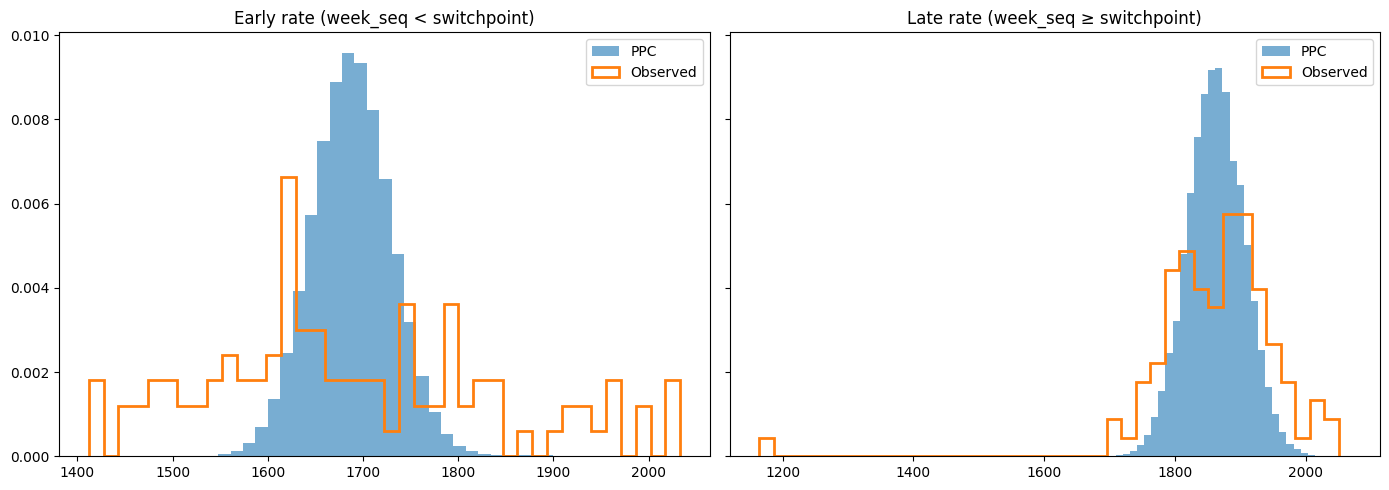

In [54]:
switchpoint_hat = sev_samples.posterior['switchpoint'].mean().item()

crimes_obs = sev_samples.observed_data['crimes'].values # get observed data
crimes_ppc = sev_samples.posterior_predictive['crimes'].values
crimes_ppc_flat = crimes_ppc.reshape(-1, crimes_ppc.shape[-1]) # reshape data

week_seq = bayes_weekly_plot['week_seq'].values

early_mask = week_seq < switchpoint_hat
late_mask  = week_seq >= switchpoint_hat

# observed
crimes_obs_early = crimes_obs[early_mask]
crimes_obs_late  = crimes_obs[late_mask]

# posterior predictive
crimes_ppc_early = crimes_ppc_flat[:, early_mask].ravel()
crimes_ppc_late  = crimes_ppc_flat[:, late_mask].ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(crimes_ppc_early, bins=40, density=True, alpha=0.6, label='PPC')
axes[0].hist(
    crimes_obs_early,
    bins=40,
    density=True,
    histtype='step',
    linewidth=2,
    label='Observed'
)
axes[0].set_title('Early rate (week_seq < switchpoint)')
axes[0].legend()

axes[1].hist(crimes_ppc_late, bins=40, density=True, alpha=0.6, label='PPC')
axes[1].hist(
    crimes_obs_late,
    bins=40,
    density=True,
    histtype='step',
    linewidth=2,
    label='Observed'
)
axes[1].set_title('Late rate (week_seq ≥ switchpoint)')
axes[1].legend()

plt.tight_layout()
plt.show()


Here we see that the early rate does not appear to be one Poisson data set but perhaps multiple rates. The late rate has much higher dispersion than we modeled for with our Poisson likelihood function, so we should switch to a likelihood function that allows for dispersion, such as a negative binomial. In addition, because of the wide dispersion of the early rate, we could model this with two separate alphas. Our goal now is to find when the crime rates "returned to normal post-COVID," so we will continue with the split, but provide a general fit to the early period and deal more specifically with the late period. 

#### 4.1.3 Changing to a Negative Binomial Model Assumption

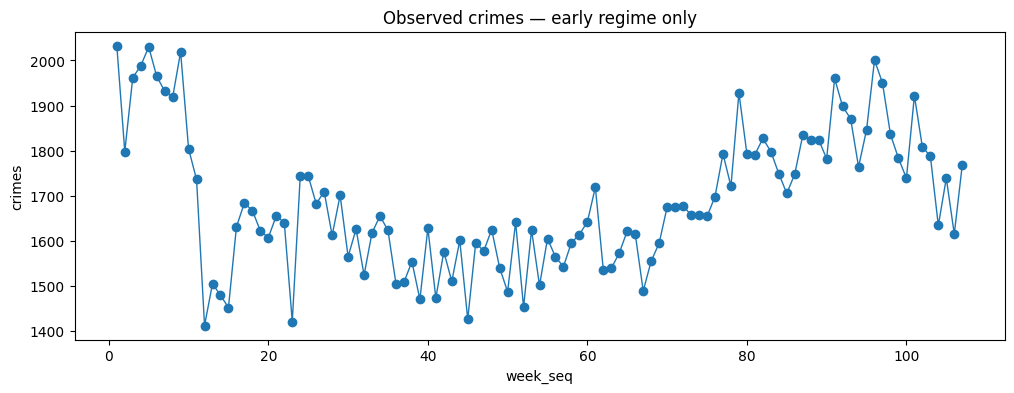

In [55]:
T = sev_samples.observed_data['crimes'].shape[0]
idx = np.arange(T)
early_idx = idx[early_mask]

plt.figure(figsize=(12,4))
plt.plot(week_seq[early_mask], crimes_obs[early_mask], marker='o', linewidth=1)
plt.title("Observed crimes — early regime only")
plt.xlabel("week_seq")
plt.ylabel("crimes")
plt.show()


The early crime rate (before week 108) looks as if there may be 3 or more distinct crime rate "periods". We can smooth this over by just assuming a wide dispersion for now.

Sampling: [alpha_early, alpha_late, crimes, early_rate, late_rate, switchpoint]


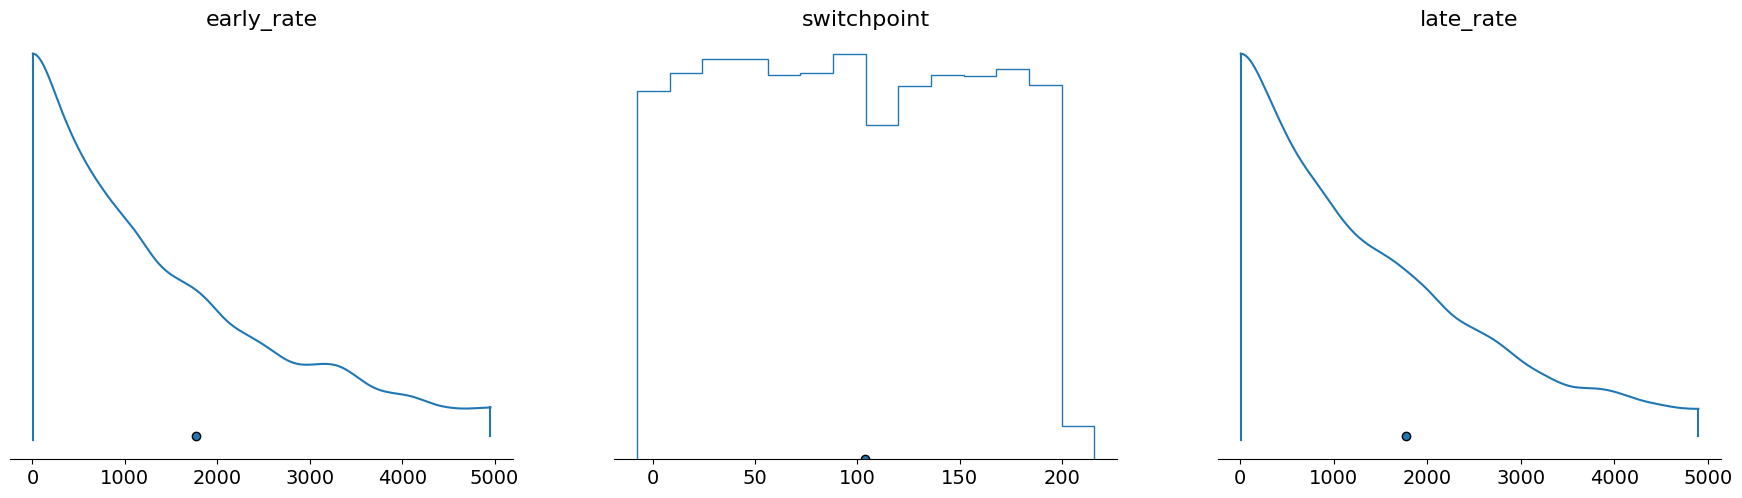

In [56]:
week_seq = bayes_weekly_plot['week_seq'].values
crime_count = bayes_weekly_plot['crime_count'].values
T = len(crime_count)
t = np.arange(T)

# we can try to calculate alpha from the data we got on switchpoint in the previous study
early = crime_count[t < int(round(108))]
m = early.mean()
v = early.var()
alpha_hat_early = m*m / (v - m) if v > m else np.inf

late = crime_count[t >= int(round(108))]
m = late.mean()
v = late.var()
alpha_hat_late = m*m / (v - m) if v > m else np.inf


with pymc.Model() as sev_bayes2:
    switchpoint = pymc.DiscreteUniform("switchpoint", lower=0, upper= T - 1)

    n_for_exp = crime_count.mean()
    early_rate = pymc.Exponential("early_rate", 1 / n_for_exp)
    late_rate  = pymc.Exponential("late_rate", 1 / n_for_exp)

    const_alpha = 5
    const_beta = 2

    alpha_early = pymc.Gamma("alpha_early", alpha = const_alpha, beta = const_alpha/ (const_beta * alpha_hat_early))
    alpha_late = pymc.Gamma("alpha_late", alpha = const_alpha, beta = const_alpha/(const_beta * alpha_hat_late))

    
    rate = pymc.math.switch(t < switchpoint, early_rate, late_rate)
    alpha = pymc.math.switch(t < switchpoint, alpha_early, alpha_late)

    sev2crimes2 = pymc.NegativeBinomial(
        "crimes",
        mu=rate,
        alpha=alpha,
        observed=crime_count
    )

with sev_bayes2:
    prior_checks2 = pymc.sample_prior_predictive(samples=5000)

_ = az.plot_density(prior_checks, group="prior")

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [early_rate, late_rate, alpha_early, alpha_late]
>Metropolis: [switchpoint]


Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 6 seconds.


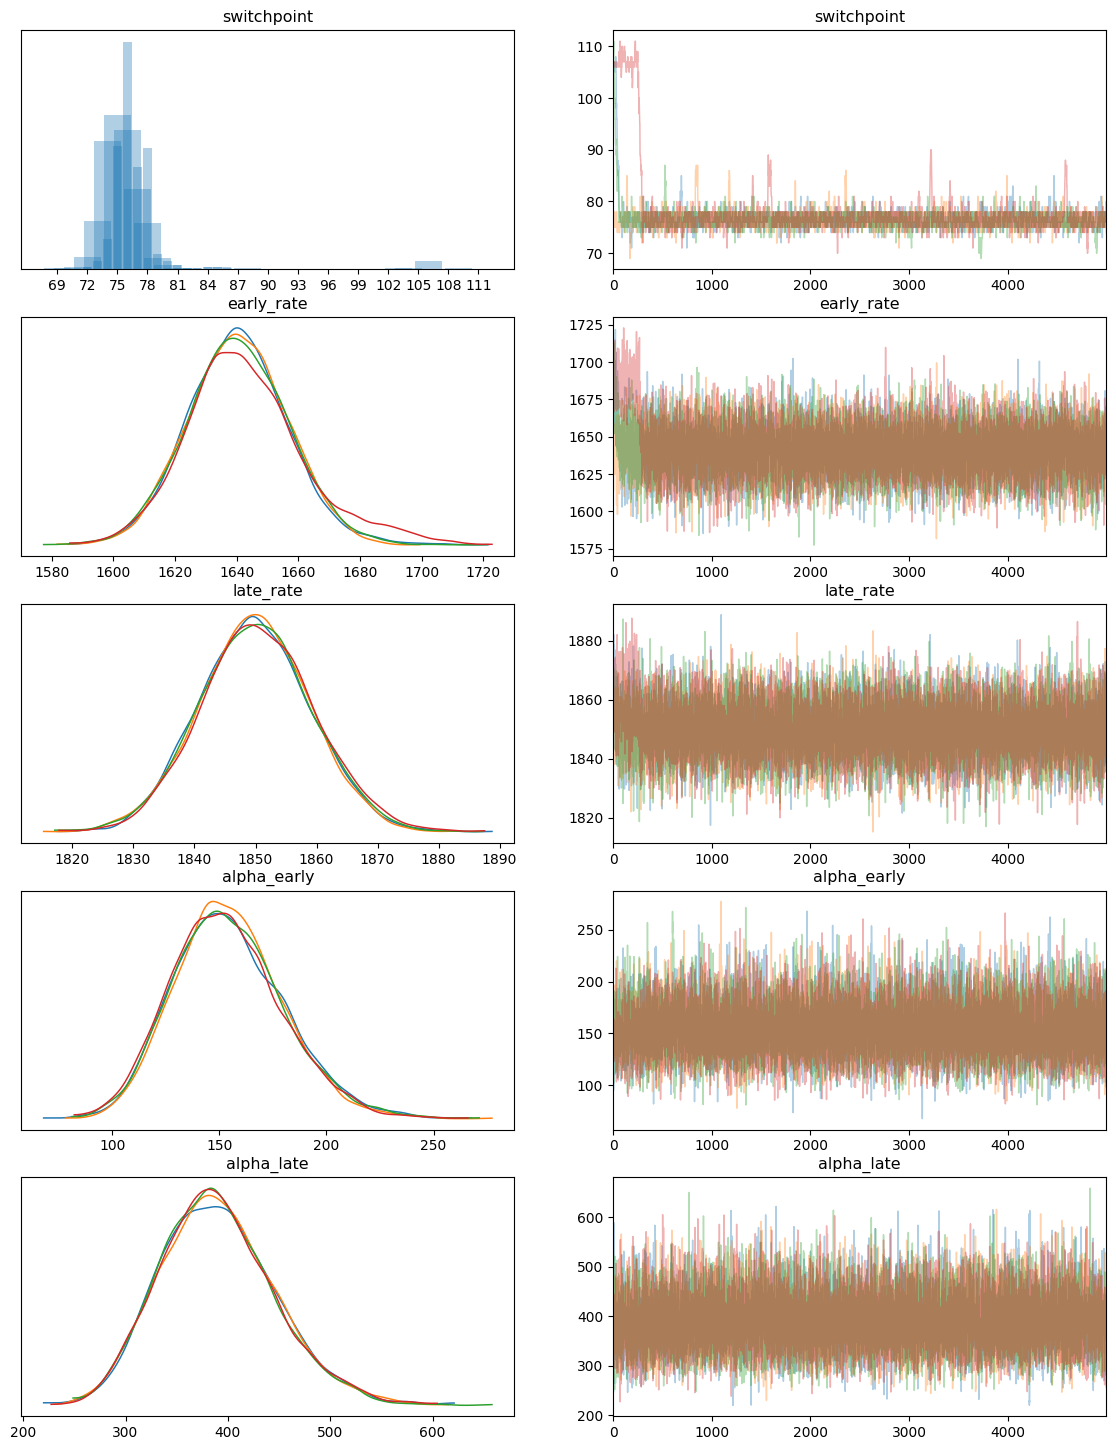

In [57]:
# RNDSEED = 5555
with sev_bayes2:
    # sev_samples2 = pymc.sample(draws = 5000, return_inferencedata = True, step = [pymc.NUTS(target_accept=0.95, max_treedepth=60)], random_seed = RNDSEED)
    sev_samples2 = pymc.sample(draws = 5000, return_inferencedata = True, step = [pymc.NUTS(target_accept=0.95, max_treedepth=60)])
_ = az.plot_trace(sev_samples2, compact=False, figsize = (14,18))

             mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
switchpoint      0.545    0.399     559.0     174.0   1.01
early_rate       0.738    0.529     780.0     199.0   1.00
late_rate        0.141    0.100    4453.0    4868.0   1.00
alpha_early      0.181    0.130   20077.0   13420.0   1.00
alpha_late       0.382    0.273   21645.0   15287.0   1.00


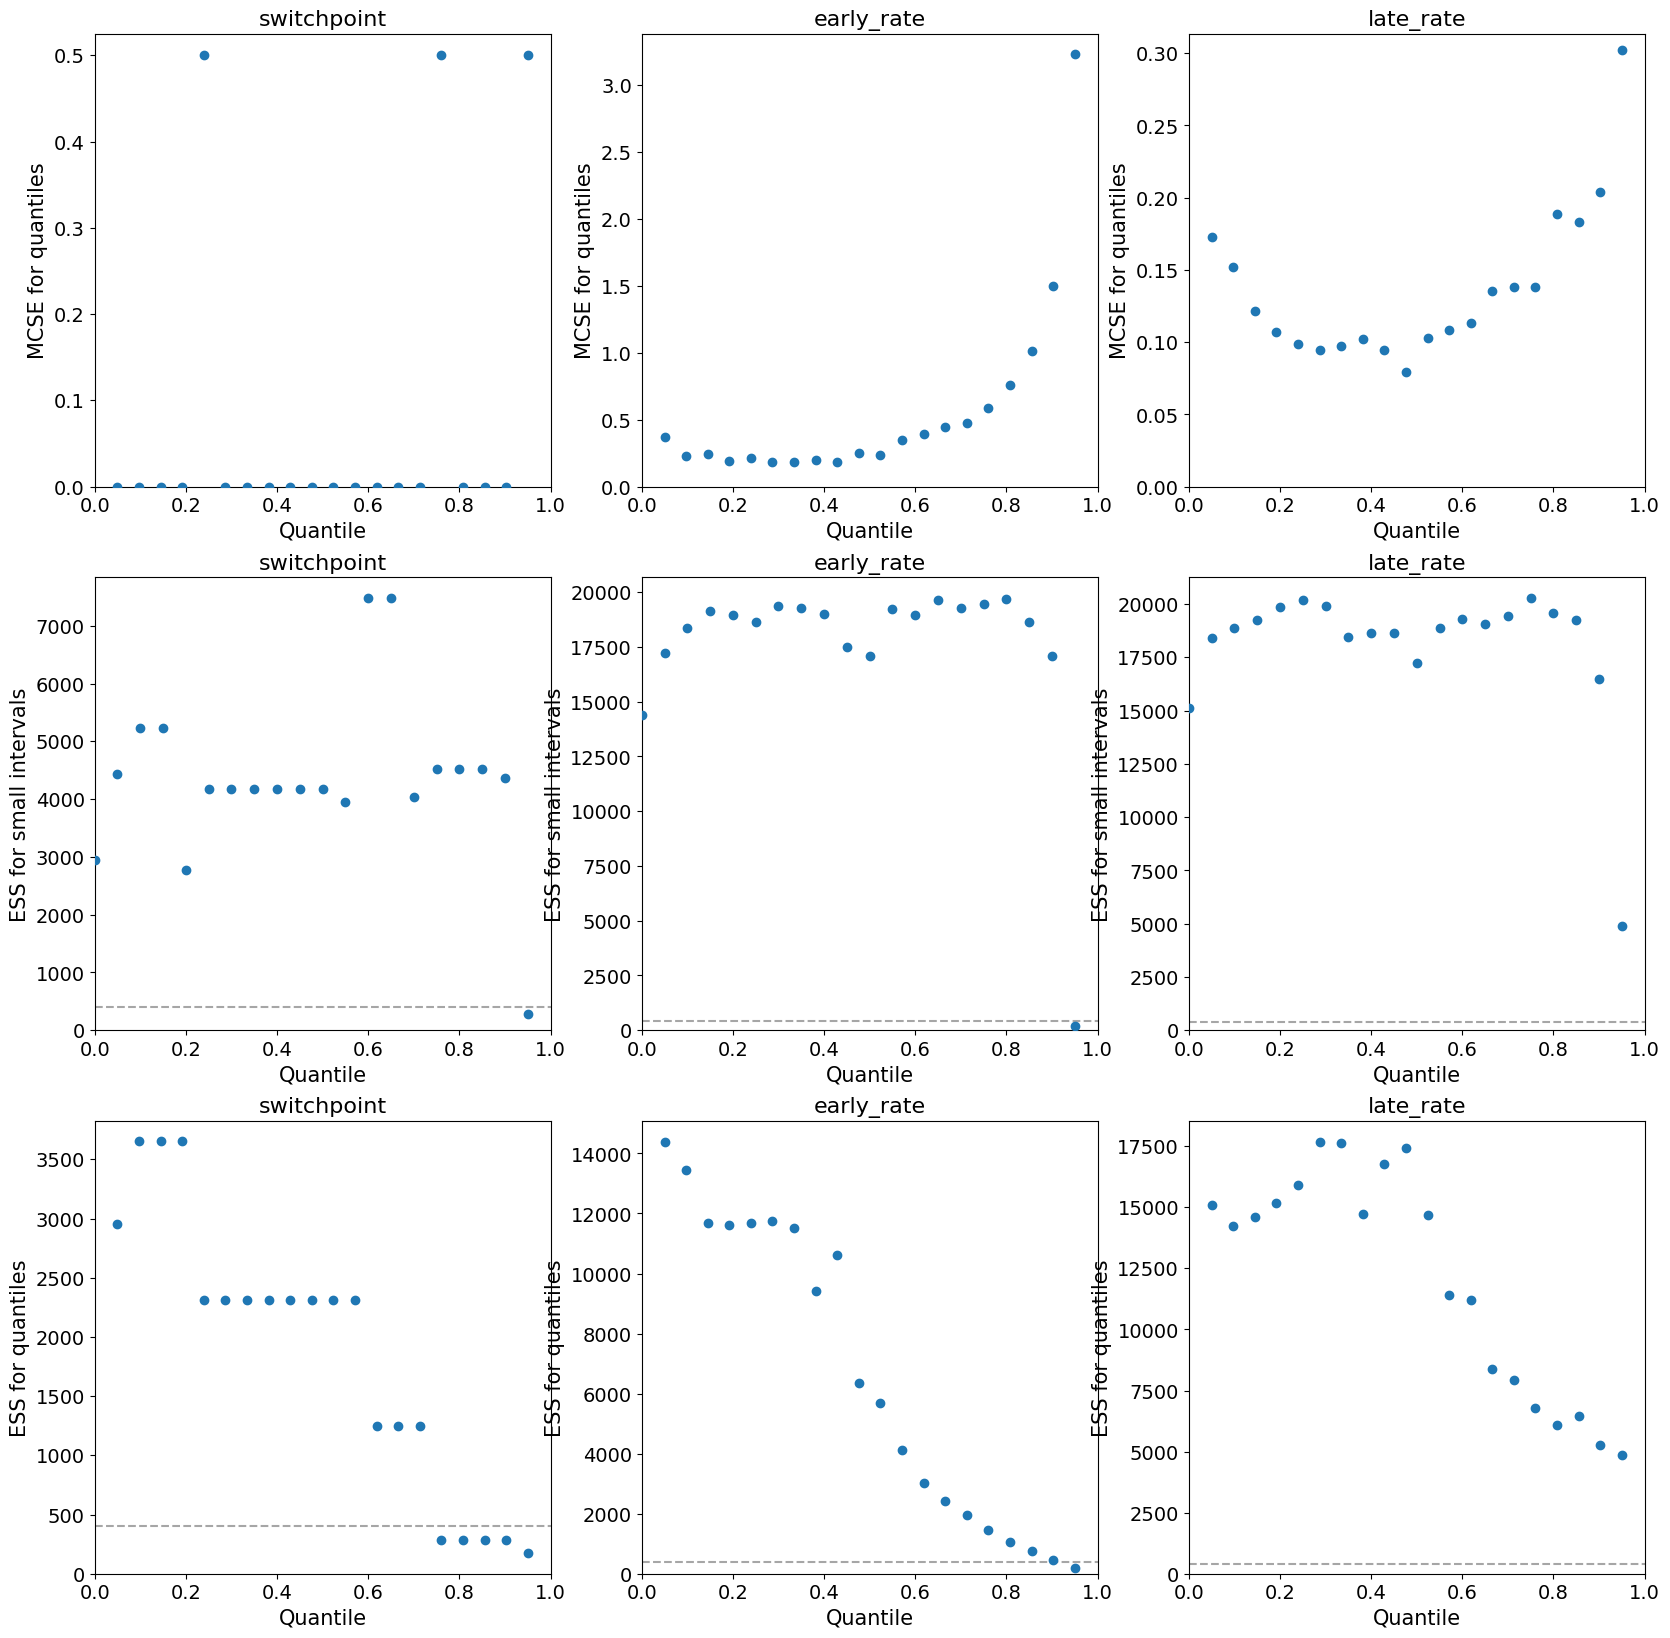

In [58]:
print(az.summary(sev_samples2, kind = "diagnostics"))

_,ax = plt.subplots(3,3, figsize=(20,20))
az.plot_mcse(sev_samples2, ax=ax[0])
az.plot_ess(sev_samples2, kind="local", ax=ax[1]);
az.plot_ess(sev_samples2, kind="quantile", ax=ax[2]);

Once again our sampling methodology looks solid, with large effective samples. Our MCSE values are low relative to observed values.

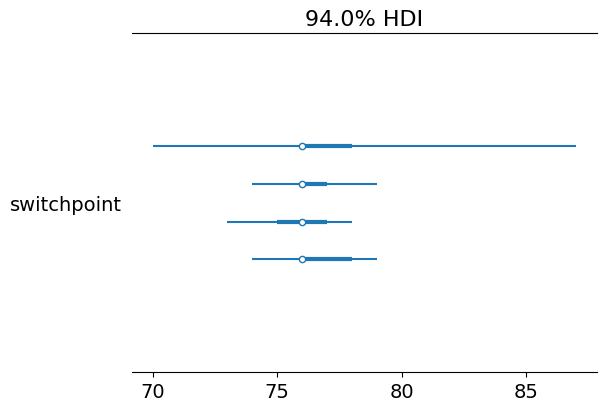

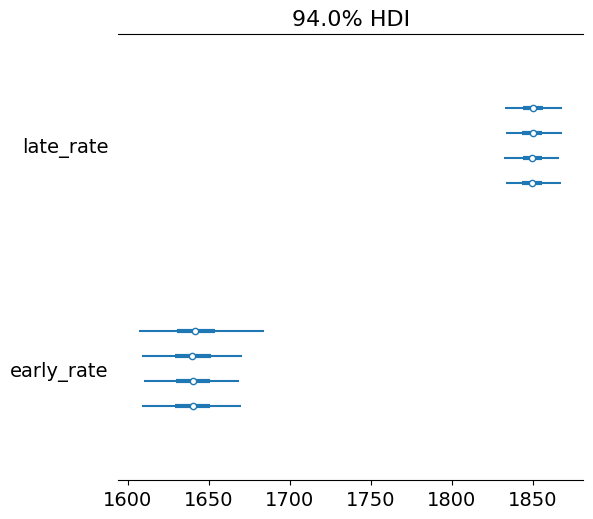

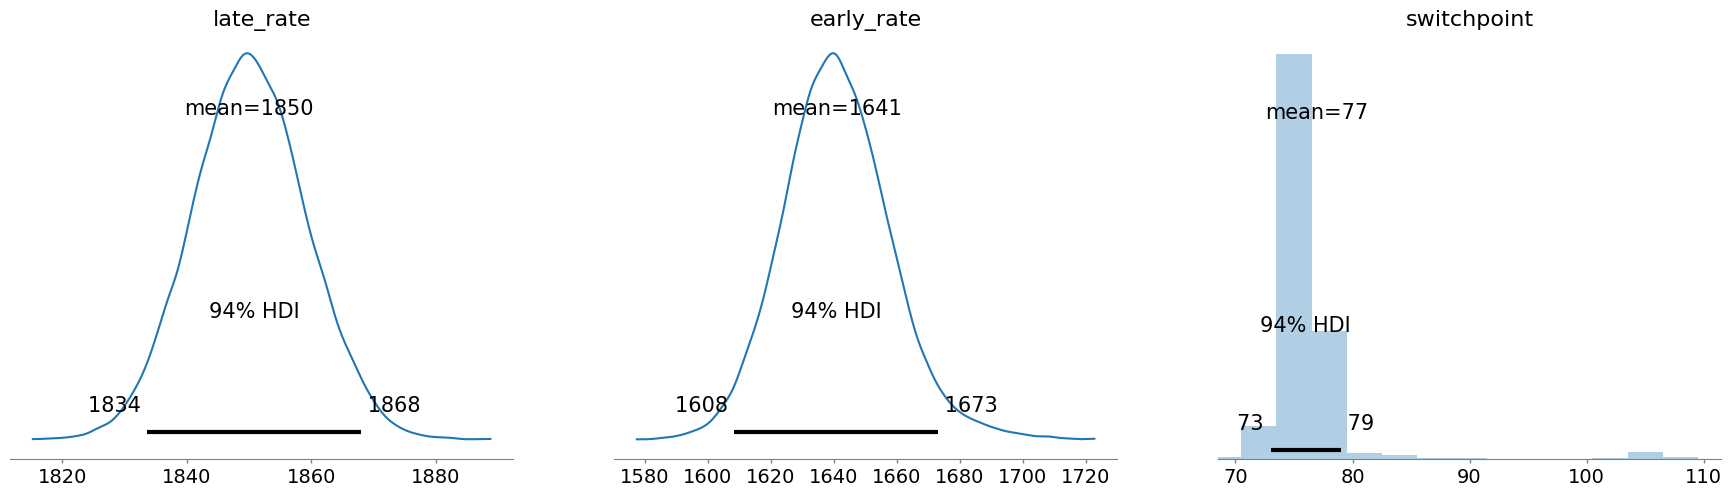

In [59]:
az.plot_forest(sev_samples2, var_names = 'switchpoint')
az.plot_forest(sev_samples2, var_names=['late_rate', 'early_rate']);
plt.show()
az.plot_posterior(sev_samples2, var_names=['late_rate', 'early_rate', 'switchpoint']); 
plt.show()

Although our early and late rates did not change too much (<1% change in late rate, and around 3% change in the early rate), this new model estimates our switch point to be around 76 weeks. Next, we should take a look at the distributions.

Sampling: [crimes]


<Axes: xlabel='crimes'>

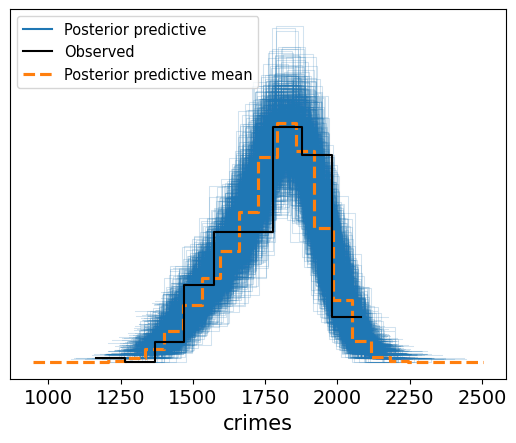

In [60]:
with sev_bayes2:
    pymc.sample_posterior_predictive(sev_samples2, extend_inferencedata = True)
az.plot_ppc(sev_samples2, num_pp_samples=1000)

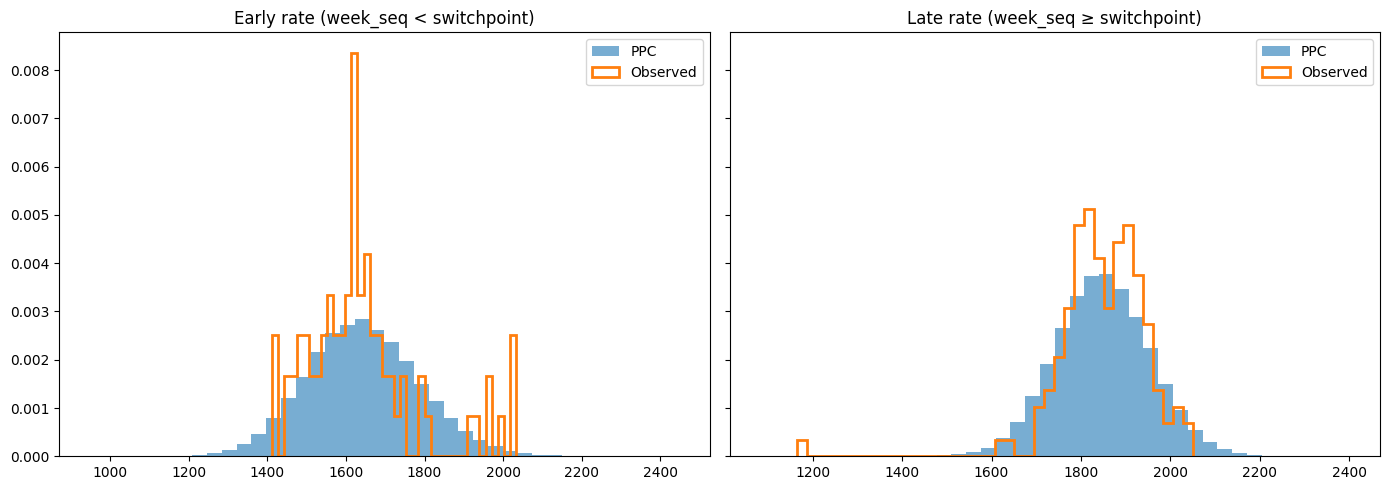

In [61]:
switchpoint_hat2 = sev_samples2.posterior['switchpoint'].mean().item()
early_mask2 = t < switchpoint_hat2
late_mask2  = t >= switchpoint_hat2

crimes_obs2 = sev_samples2.observed_data['crimes'].values  # observed data
crimes_ppc2 = sev_samples2.posterior_predictive['crimes'].values
crimes_ppc_flat2 = crimes_ppc2.reshape(-1, crimes_ppc2.shape[-1])  # reshape data

T = len(crimes_obs2)
t = np.arange(T)
week_seq2 = bayes_weekly_plot['week_seq'].values

# observed
crimes_obs_early2 = crimes_obs2[early_mask2]
crimes_obs_late2  = crimes_obs2[late_mask2]

# posterior predictive
crimes_ppc_early2 = crimes_ppc_flat2[:, early_mask2].ravel()
crimes_ppc_late2  = crimes_ppc_flat2[:, late_mask2].ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(crimes_ppc_early2, bins=40, density=True, alpha=0.6, label='PPC')
axes[0].hist(
    crimes_obs_early2,
    bins=40,
    density=True,
    histtype='step',
    linewidth=2,
    label='Observed'
)
axes[0].set_title('Early rate (week_seq < switchpoint)')
axes[0].legend()

axes[1].hist(crimes_ppc_late2, bins=40, density=True, alpha=0.6, label='PPC')
axes[1].hist(crimes_obs_late2,
    bins=40,
    density=True,
    histtype='step',
    linewidth=2,
    label='Observed'
)
axes[1].set_title('Late rate (week_seq ≥ switchpoint)')
axes[1].legend()

plt.tight_layout()
plt.show()


Our initial model did not fit because of lack of dispersion and failed to capture the variance of the data set. We achieved a better fit by switching from a Poisson likelihood to a negative binomial likelihood, from: 
$
Y_t \sim \text{Poisson}(\lambda_t)$ to: $Y_t \sim \text{NegativeBinomial}(\mu_t, \alpha)$

However, our early crime data is likely not fixed by this switch. The weekly crime rates in this period look heterogenous and probably cannot be fit by just one model. We would likely need a deeper dive. For example: Our new model predicts the switchpoint at around week 76, which is in the range of June 2021. California state wide quarantines ended January of 2021, which would be from week 52 to week 56. Intuitively, we should expect a switch in rates around that time, but using a single switchpoint might not capture the smaller trend within the larger trend of a binary switch.

#### 4.1.4 Building a Hierarchical Bayesian Model for Area-Level Crime

Let's move forward, with the tentative conclusion that the crime rate increased after June 2021 by about 200 crimes per week. Perhaps we can investigate how crime reacted in each community in a hierarchical model. Initially, we let the switchpoint, early, and late rates be area specific, but shared an early and late alpha for dispersions, based on our data above. 

However, in test runs of this model, an area-specific (partially pooled) switchpoint caused the model to run extremely slow. If we instead choose to evaluate data as a result of state-wide policies, we speed up the NUTS sampler on the posterior by a large margin.

In [62]:
# preparing the dataset, keeping the area data column
weekly_plot_area = lacrime.groupby(['week_seq', 'severity', 'AREA']).size().reset_index(name = 'crime_count')
# begin building our model similar to how the radon study was constructed
sev = 2
df = weekly_plot_area[weekly_plot_area['severity'] == sev].copy()

area_idxs, areas = pd.factorize(df.AREA)

coords = {"area": areas, "obs_id": np.arange(len(df))}

df.loc[:, "area_idx"] = area_idxs

week_vals = np.sort(df['week_seq'].unique())
week_map = {w: i for i, w in enumerate(week_vals)}
df["t"] = df["week_seq"].map(week_map)

y = df['crime_count'].values.astype(int)

A = len(areas)
T = len(week_vals)
N = len(y)

In [63]:
with pymc.Model(coords = coords) as hier_area:
    mu_early = pymc.Normal("mu_early", mu = np.log(y.mean()), sigma = 0.5)
    sigma_early = pymc.HalfNormal("sigma_early", sigma = 0.5)

    mu_late = pymc.Normal("mu_late", mu = np.log(y.mean()), sigma = 0.5)
    sigma_late = pymc.HalfNormal("sigma_late", sigma = 0.5)

    # mu_sp = pymc.Normal("mu_sp", mu = len(week_vals) / 2, sigma = len(week_vals) / 6)
    # sigma_sp = pymc.HalfNormal("sigma_sp", sigma = len(week_vals) / 6)

    # assume normal dist for shared attributes
    z_early = pymc.Normal("z_early", mu = 0.0, sigma = 1, dims = "area")
    z_late  = pymc.Normal("z_late",  mu = 0.0, sigma = 1, dims = "area")
    # z_sp    = pymc.Normal("z_sp",    mu = 0.0, sigma = 1, dims = "area")


    early_rate  = pymc.Deterministic("early_rate",pymc.math.exp(mu_early + sigma_early * z_early))
    late_rate   = pymc.Deterministic("late_rate", pymc.math.exp(mu_late + sigma_late * z_late))
    # sp = mu_sp + sigma_sp * z_sp
    # switchpoint = pymc.Deterministic("switchpoint", pymc.math.clip(pymc.math.round(sp), 0, len(week_vals)-1), dims = "area")

    switchpoint_cont = pymc.Normal("switchpoint_cont", mu = len(week_vals) / 2, sigma = len(week_vals) / 6)
    switchpoint = pymc.Deterministic("switchpoint", pymc.math.clip(pymc.math.round(switchpoint_cont), 0, len(week_vals) - 1))

    # post = df["t"].values >= switchpoint[df['area_idx'].values]
    post = df["t"].values >= switchpoint

    mu = pymc.math.switch(post, late_rate[df['area_idx'].values], early_rate[df['area_idx'].values])

    # we will use the same alphas we calculated earlier for now
    alpha_early = pymc.Gamma("alpha_early", alpha = 5, beta = 5 / alpha_hat_early)
    alpha_late = pymc.Gamma("alpha_late", alpha = 5, beta = 5 / alpha_hat_late)
    alpha = pymc.math.switch(post, alpha_late, alpha_early)

    crimes = pymc.NegativeBinomial(
        "crimes",
        mu=mu,
        alpha=alpha,
        observed=y,
        dims="obs_id"
    )

This is quite a computationally intensive step, as we are running 4000 draws on a dataset with area-level effects. As we will see later, the piecewise function for switchpoint introduces a discontinuity that significantly slows down analysis. Instead, we run the sample once, save it, and then import it for future usage. We use the same technique below.

In [64]:
# with hier_area:
#     hier_trace = pymc.sample(draws = 4000, tune = 4000, target_accept = 0.95, return_inferencedata = True)
# az.to_netcdf(hier_trace, "hier_area_global_sp.nc")
hier_trace = az.from_netcdf("hier_area_global_sp.nc")

area_names = coords["area"]

for v in ["early_rate", "late_rate"]:
    hier_trace.posterior[v] = (
        hier_trace.posterior[v]
        .rename({f"{v}_dim_0": "area"})
        .assign_coords(area=area_names)
    )

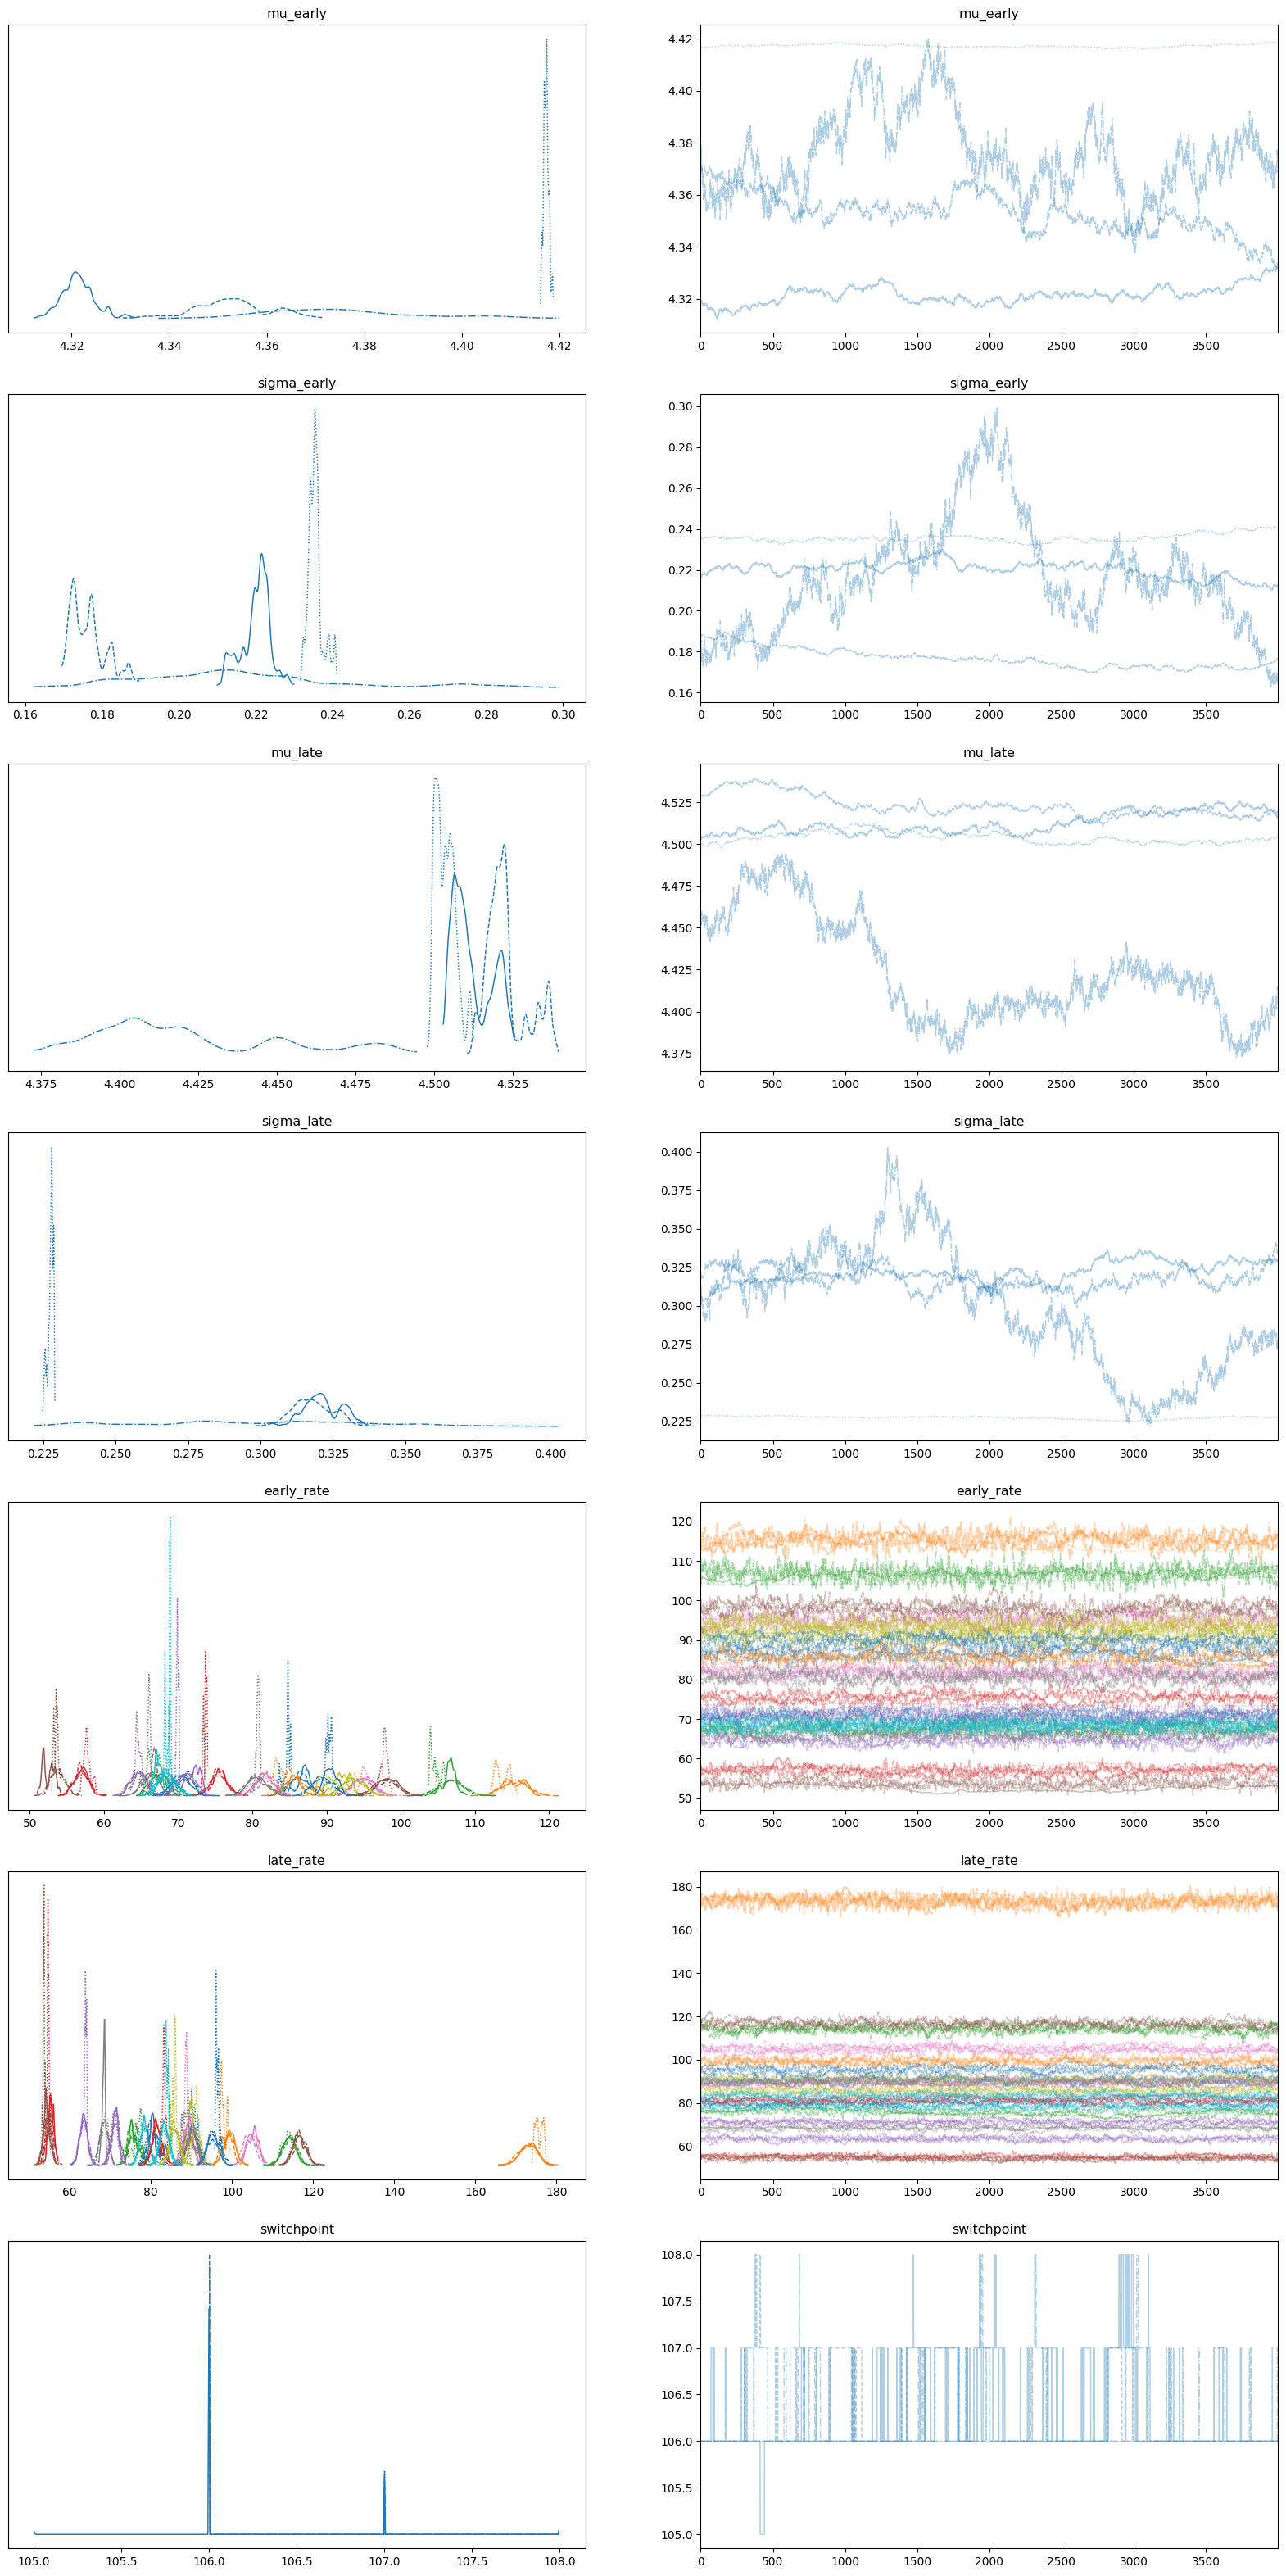

In [65]:
_ = az.plot_trace(hier_trace, var_names = ['mu_early', 'sigma_early', 'mu_late', 'sigma_late', 'early_rate', 'late_rate', 'switchpoint'], combined = False, figsize=(20,40))

Obviously we should see different densities per area for early and late rates, this part is expected. The switchpoint is also centered around 106 or 107, which seems reasonable as it agrees with our initial Poisson analysis. However, we got many different values for mu and sigma for both the late and early rates. We are plotting multiple chains, and it shows that several different mu and sigma values could explain our data. Overall, the results are not as clean as we saw for the Radon mine analysis. Our sigma values especially are very noisy.

In [66]:
az.summary(hier_trace).sort_values(by = 'ess_bulk', ascending = True)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_early,4.367,0.036,4.319,4.419,0.018,0.013,5.0,16.0,2.84
z_late[Newton],-0.449,0.168,-0.699,-0.089,0.077,0.058,5.0,27.0,2.24
z_late[N Hollywood],0.063,0.157,-0.117,0.400,0.074,0.056,5.0,15.0,2.13
z_late[Mission],-0.927,0.207,-1.307,-0.544,0.096,0.074,5.0,21.0,2.37
z_late[Hollywood],0.571,0.187,0.298,0.945,0.088,0.067,5.0,12.0,2.43
...,...,...,...,...,...,...,...,...,...
late_rate[Southwest],116.628,1.548,113.736,119.462,0.118,0.084,173.0,577.0,1.02
early_rate[Van Nuys],80.644,1.177,78.455,83.174,0.082,0.058,200.0,434.0,1.24
alpha_late,97.118,6.366,85.585,109.213,0.425,0.301,211.0,291.0,1.01
late_rate[Newton],78.468,1.136,76.420,80.610,0.078,0.056,212.0,475.0,1.01


This chart is more alarming and shows a more serious sampling problem: our ESS on several values is extremely low. In addition, r_hat values are well over 1 in many cases, and even in the best case are over 1. This implies that the different chains are not well mixed and are exploring different regions of the posterior distribution. Our posterior summaries are unreliable. We ran the analysis with 4000 tuning steps and 4000 draws (and 4 chains) and are seeing a bulk ESS of under 300 even in the best cases. Overall, our model fit did not converge.

#### 4.1.5 Applying a Sigmoid Switchpoint Function

One suggestion I have seen is that a hard switchpoint is a discontinuous part of the likelihood and posterior and that switching to a "soft" switchpoint can help alleviate some of these issues and make it easier for our samples to explore the posterior. Our NUTS method will likely perform better (and faster) with a continuous function. Below, we change over the switchpoint to a sigmoid function that introduces a gradual switch from the early to late rate rather than a piecewise discrete switch, hopefully with better results.


In [67]:
# sigmoid switchpoint
with pymc.Model(coords = coords) as hier_area2:
    mu_early = pymc.Normal("mu_early", mu = np.log(y.mean()), sigma = 0.5)
    sigma_early = pymc.HalfNormal("sigma_early", sigma = 0.5)

    mu_late = pymc.Normal("mu_late", mu = np.log(y.mean()), sigma = 0.5)
    sigma_late = pymc.HalfNormal("sigma_late", sigma = 0.5)

    # mu_sp = pymc.Normal("mu_sp", mu = len(week_vals) / 2, sigma = len(week_vals) / 6)
    # sigma_sp = pymc.HalfNormal("sigma_sp", sigma = len(week_vals) / 6)

    # assume normal dist for shared attributes
    z_early = pymc.Normal("z_early", mu = 0.0, sigma = 1, dims = "area")
    z_late  = pymc.Normal("z_late",  mu = 0.0, sigma = 1, dims = "area")
    # z_sp    = pymc.Normal("z_sp",    mu = 0.0, sigma = 1, dims = "area")

    # eps = pymc.HalfCauchy("eps", 5.0) # alpha estimates our noise

    early_rate  = pymc.Deterministic("early_rate",pymc.math.exp(mu_early + sigma_early * z_early))
    late_rate   = pymc.Deterministic("late_rate", pymc.math.exp(mu_late + sigma_late * z_late))
    # sp = mu_sp + sigma_sp * z_sp
    # switchpoint = pymc.Deterministic("switchpoint", pymc.math.clip(pymc.math.round(sp), 0, len(week_vals)-1), dims = "area")

    switchpoint = pymc.Normal("switchpoint", mu = len(week_vals) / 2, sigma = len(week_vals) / 6)
    tau = pymc.HalfNormal("tau", sigma = 2.0)
    
    t = df["t"].values
    area_idx = df["area_idx"].values
    
    w = pymc.math.sigmoid((t - switchpoint) / tau)

    mu = ((1 - w) * early_rate[area_idx] + w * late_rate[area_idx])

    # we will use the same alphas we calculated earlier for now
    alpha_early = pymc.Gamma("alpha_early", alpha = 5, beta = 5 / alpha_hat_early)
    alpha_late = pymc.Gamma("alpha_late", alpha = 5, beta = 5 / alpha_hat_late)
    alpha = ((1 - w) * alpha_early + w * alpha_late)


    crimes = pymc.NegativeBinomial(
        "crimes",
        mu=mu,
        alpha=alpha,
        observed=y,
        dims="obs_id"
    )

In [68]:
# with hier_area2:
#     hier_trace2 = pymc.sample(draws = 4000, tune = 4000, target_accept = 0.95, return_inferencedata = True)
# az.to_netcdf(hier_trace2, "hier_area2_global_sp.nc")
hier_trace2 = az.from_netcdf("hier_area2_global_sp.nc")

# rename variables for better readability:
area_names = coords["area"]

for v in ["early_rate", "late_rate"]:
    hier_trace2.posterior[v] = (
        hier_trace2.posterior[v]
        .rename({f"{v}_dim_0": "area"})
        .assign_coords(area=area_names)
    )

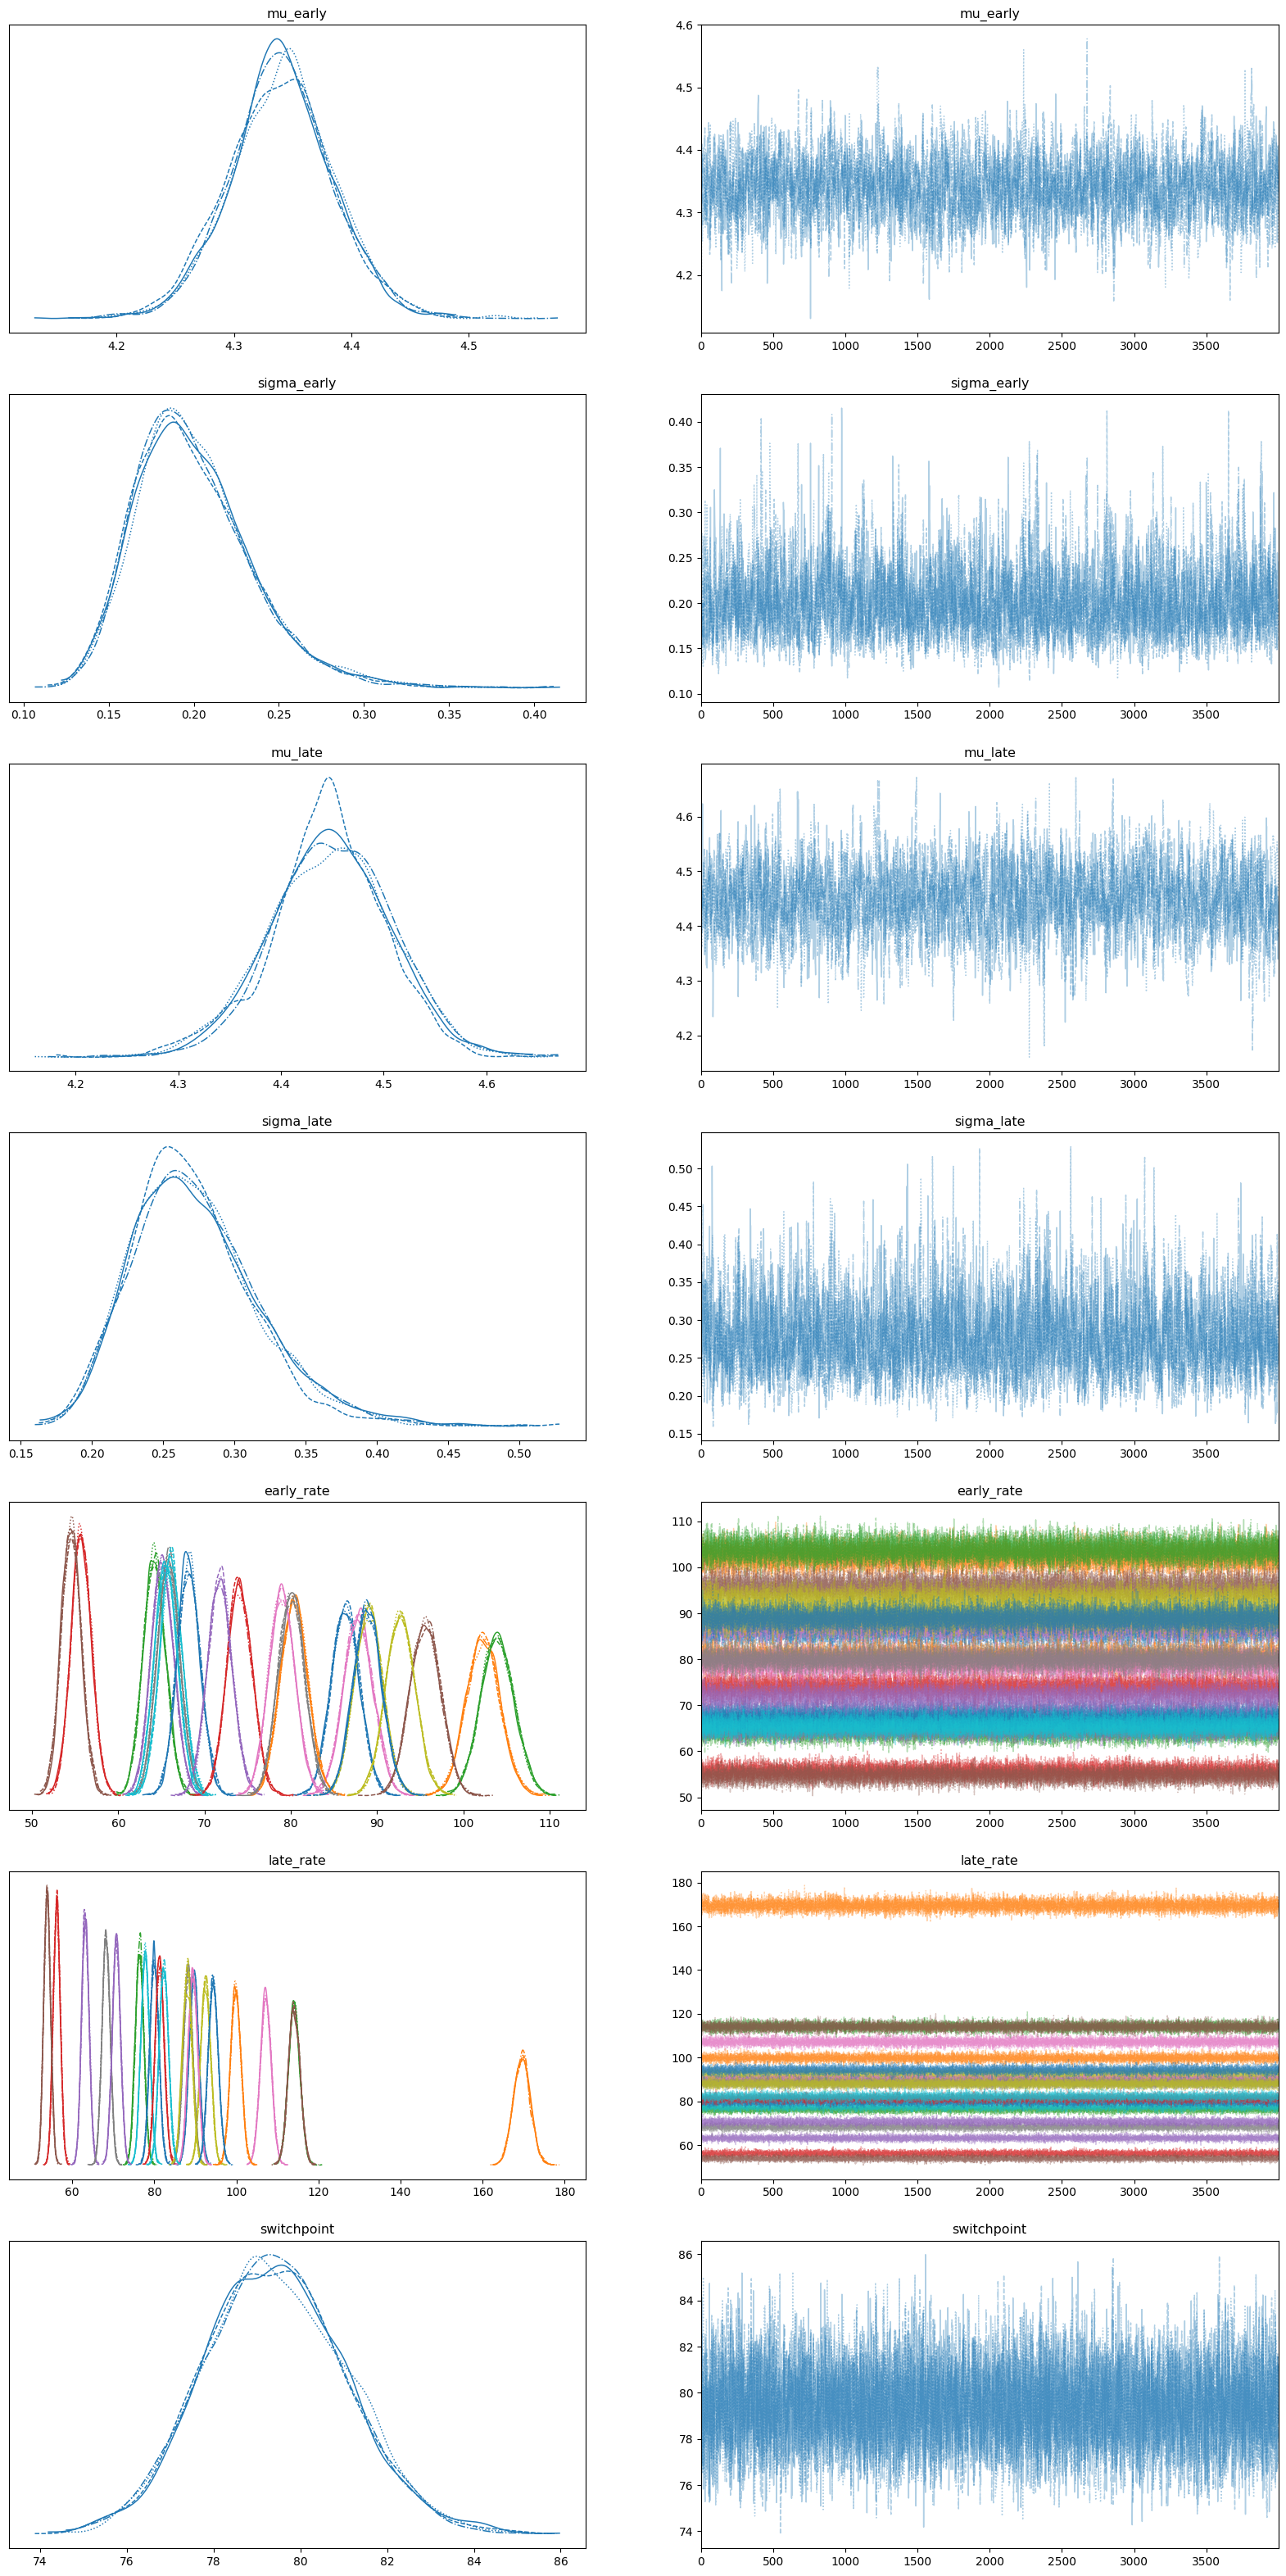

In [69]:
# az.plot_trace(hier_trace, var_names = ['mu_early', 'sigma_early', 'mu_late', 'sigma_late', 'mu_sp', 'sigma_sp', 'early_rate', 'late_rate', 'switchpoint'], figsize=(20,40))
_ = az.plot_trace(hier_trace2, var_names = ['mu_early', 'sigma_early', 'mu_late', 'sigma_late', 'early_rate', 'late_rate', 'switchpoint'], combined = False, figsize=(20,40))

In [70]:
az.summary(hier_trace2).sort_values(by = 'ess_bulk', ascending = True)
# az.summary(hier_trace2).sort_values(by = 'mcse_mean', ascending = False)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_late,4.448,0.058,4.341,4.560,0.002,0.001,1466.0,2061.0,1.0
z_late[77th Street],0.182,0.217,-0.235,0.581,0.006,0.004,1491.0,2295.0,1.0
z_late[West LA],0.112,0.216,-0.301,0.511,0.006,0.004,1500.0,2427.0,1.0
z_late[N Hollywood],0.298,0.220,-0.099,0.724,0.006,0.004,1504.0,2464.0,1.0
z_late[Wilshire],0.373,0.222,-0.028,0.797,0.006,0.004,1511.0,2619.0,1.0
...,...,...,...,...,...,...,...,...,...
early_rate[77th Street],86.353,1.630,83.212,89.294,0.011,0.008,22500.0,10936.0,1.0
early_rate[Devonshire],64.187,1.306,61.745,66.640,0.009,0.006,22523.0,12602.0,1.0
early_rate[Wilshire],88.908,1.668,85.820,92.080,0.011,0.008,22700.0,11580.0,1.0
early_rate[West Valley],65.537,1.319,63.049,67.985,0.009,0.006,22791.0,12664.0,1.0


Moving over to a sigmoid switchpoint showed much improved results at least in the model diagnostics. Our $\mu$ and $\sigma$ KDEs line up and the chains overlap tightly. $\mu$ and $\sigma$ values are unimodal and consistent. Unlike previously, there is no separation of chains and multimodal or otherwise pathological behaviors. 

Looking at our density plots, we have much better overlap in early and late rates across our 4 chains. Our curves are also taller implying that the posteriors are more highly concentrated with lower uncertainty overall and better information. Lastly, our switchpoint KDE does not have the discrete jumping behavior observed before, but instead a mostly normal looking plot centered around approximately 79, similar to what we observed in our pooled model with a negative binomial likelihood.

Our model summary shows similarly improved data. MCSE in the prior plot was not an issue, which remains the case. However, our effective sample size increased in all cases, and we have rhat values that are acceptable across the board.

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

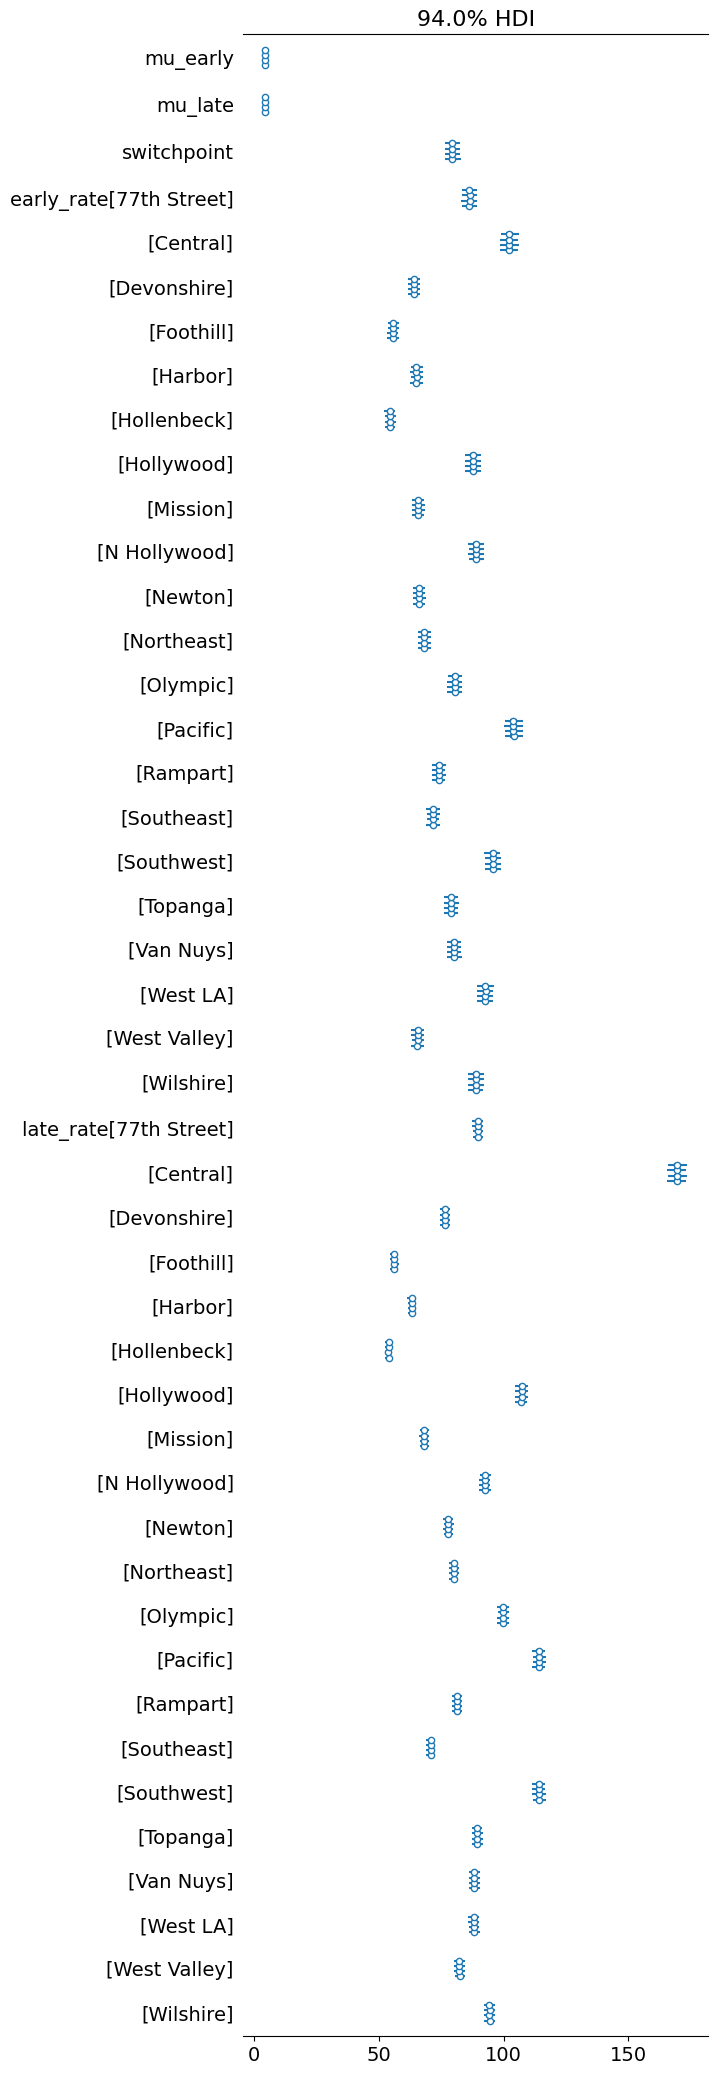

In [71]:
az.plot_forest(hier_trace2, var_names = ['mu_early', 'mu_late', 'switchpoint', 'early_rate', 'late_rate'])

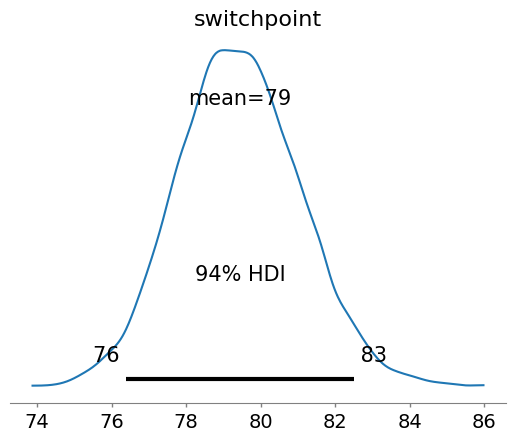

In [72]:
_ = az.plot_posterior(
    hier_trace2,
    var_names=["switchpoint"],
)

In [73]:
early_offenders = az.summary(hier_trace2).loc[lambda df: df.index.str.startswith("early")].sort_values(by = 'mean', ascending = False).head(3)
late_offenders = az.summary(hier_trace2).loc[lambda df: df.index.str.startswith("late")].sort_values(by = 'mean', ascending = False).head(3)
highest_crime_areas = pd.concat([early_offenders, late_offenders])
highest_crime_areas

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
early_rate[Pacific],103.961,1.931,100.362,107.615,0.013,0.009,21187.0,12656.0,1.0
early_rate[Central],102.311,1.962,98.497,105.909,0.014,0.010,21103.0,12697.0,1.0
early_rate[Southwest],95.604,1.759,92.479,99.041,0.012,0.008,21870.0,12626.0,1.0
late_rate[Central],169.560,2.068,165.591,173.335,0.018,0.013,13232.0,13250.0,1.0
late_rate[Pacific],114.096,1.393,111.518,116.747,0.010,0.007,19252.0,12858.0,1.0
late_rate[Southwest],114.089,1.414,111.548,116.863,0.011,0.008,16831.0,12067.0,1.0


CIs and HDIs are tight and distinct for each region. Intuitively this makes sense, as different neighborhoods have different crime rates. 

Looking at our 3 highest crime regions, we see that Central Los Angeles had the highest crime rate and a 70% increase after the switchpoint. Let's look at the crime rates for the most drastic changes to see if we can visually observe the trend in data after the 79 day mark.

In [74]:
early_mean = (hier_trace2.posterior["early_rate"].mean(dim=("chain", "draw")))
late_mean = (hier_trace2.posterior["late_rate"].mean(dim=("chain", "draw")))
rate_diff = late_mean - early_mean
# rate_diff.sortby(rate_diff, ascending = False).to_series().index.tolist()
rate_diff_sorted = (rate_diff.sortby(rate_diff, ascending=False).to_series())
rate_diff_sorted

area
Central        67.249813
Olympic        19.459932
Hollywood      19.335186
Southwest      18.484581
West Valley    16.793116
Devonshire     12.226908
Northeast      11.838528
Newton         11.688733
Topanga        10.420945
Pacific        10.134273
Van Nuys        8.140766
Rampart         7.260138
Wilshire        5.459333
N Hollywood     3.517854
77th Street     3.333181
Mission         2.429074
Foothill        0.523520
Hollenbeck     -0.640617
Southeast      -1.022028
Harbor         -1.914862
West LA        -4.680950
dtype: float64

array([[<Axes: title={'center': 'early_rate\nPacific'}>,
        <Axes: title={'center': 'early_rate\nOlympic'}>,
        <Axes: title={'center': 'early_rate\nHollywood'}>],
       [<Axes: title={'center': 'late_rate\nPacific'}>,
        <Axes: title={'center': 'late_rate\nOlympic'}>,
        <Axes: title={'center': 'late_rate\nHollywood'}>]], dtype=object)

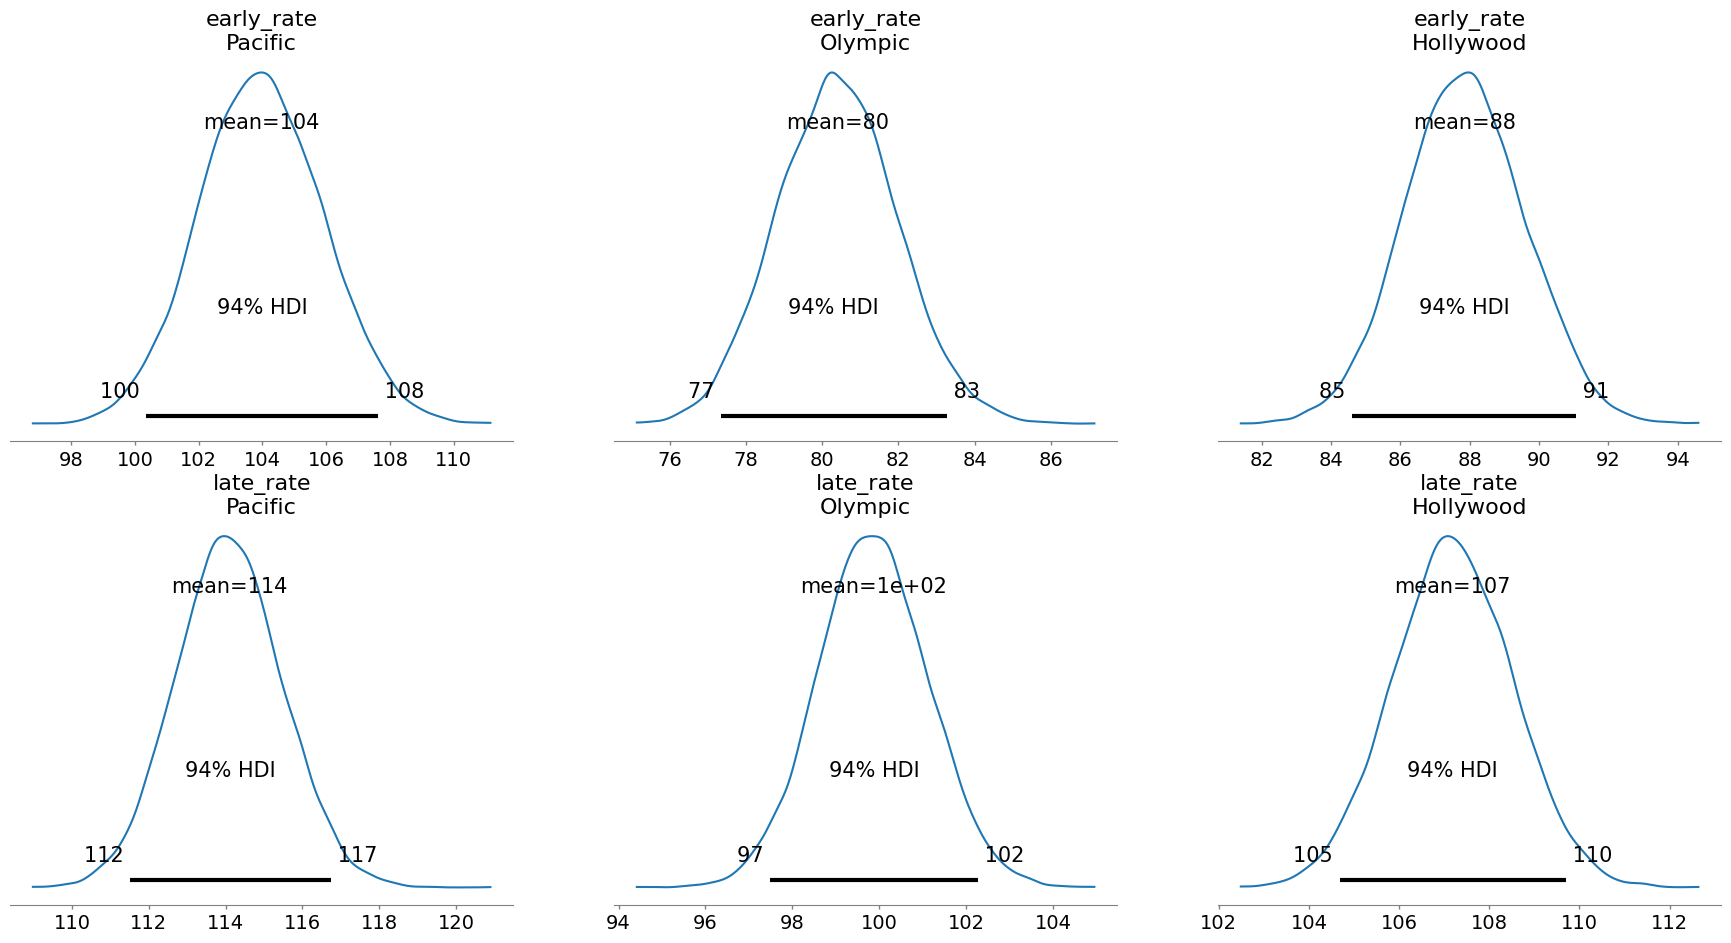

In [75]:
az.plot_posterior(
    hier_trace2,
    var_names=["early_rate", "late_rate"],
    coords={"area": ['Pacific','Olympic','Hollywood']}
)


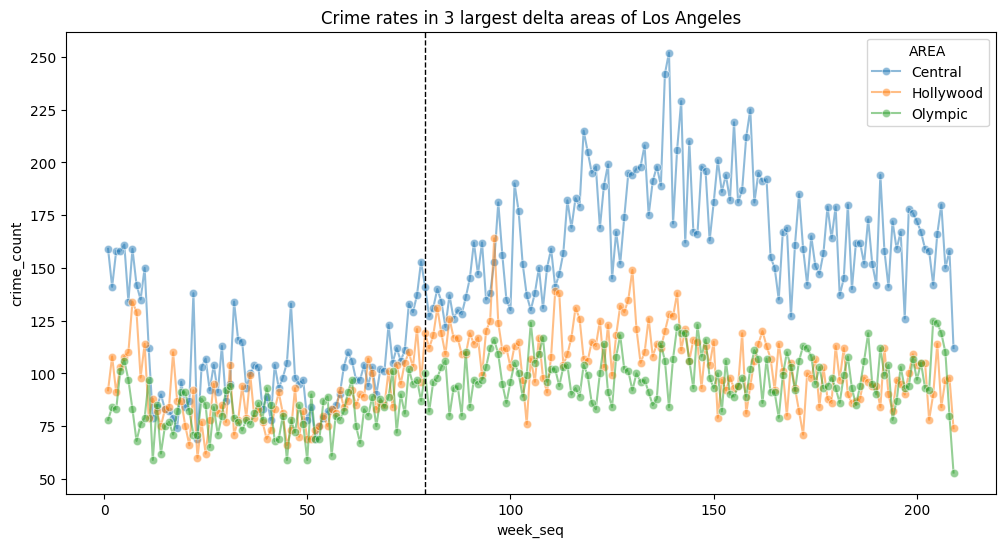

In [76]:
fig,ax = plt.subplots(figsize = (12, 6))
sns.lineplot(data = weekly_plot_area[(weekly_plot_area['severity'] == 2) 
                                     & (weekly_plot_area['AREA'].isin(['Central', 'Olympic', 'Hollywood']))]
            , x = 'week_seq'
            , y = 'crime_count'
            , hue = 'AREA'
            , ax = ax
            , marker = 'o'
            , alpha = .5
            )

ax.axvline(x = 79, color = 'black', linestyle = '--', linewidth = 1, label = 'switchpoint mean')
ax.set_title("Crime rates in 3 largest delta areas of Los Angeles")
plt.show()

#### 4.1.6 Conclusions and Future Analysis for Crime Rates by Area

The crime trend for Central seems the most convincing, although all areas do seem to have muted crime prior to the switchover. The changes are more subtle in the Olympic area. Overall, I would conclude that the "early" period likely had more structure than our simple negative binomial likelihood. However, there is a clear increase after week 79, most pronounced in Central Los Angeles.

In general, in several areas, crime rates increased after our week 79 transition. The magnitude and certainty varied by region, with obvious increases in the Central, Olympic, and Hollywood areas. The single switchpoint model is likely insufficient for a full analysis, as it seems likely there were many more events, especially in the early period. 

Our switchpoint of week 79 is sometime in June 2021. From the Wikipedia article for the [COVID-19 Pandemic in California](https://en.wikipedia.org/wiki/COVID-19_pandemic_in_California): the "majority of [the] population [was] under 'Minimal' BSE restrictions" by June 2021. BSE refers to the Blueprint for a Safer Economy, a set of restrictions that closed or opened different businesses based on the COVID rates in the area. Our estimated changepoint suggests a plausible association between the policy transition and the subsequent increase in crime rates. We would need to do a more in depth study to explore these effects, as well as controlling for other external factors exogenous to our reporting data.